# Tree-Based TCR Forecasting Prototype (Archival Version)

## Abstract
This notebook evaluates one-month-input forecasting of merchant TCR for three horizons: t+1, t+2, t+3.  
Evaluation is strictly leakage-safe using merchant-disjoint holdout and time-safe training labels.  
Multiple tree-based and hybrid methods were tested; the selected candidate for follow-up development is Method 6 (horizon-wise linear calibration of persistence).

## Menu
1. Setup and Data
2. Problem Framing and Feature/Target Construction
3. Strict Leakage-Safe Split and Audit
4. Baseline Benchmark
5. Tree-Model Family and Tuning
6. Diagnostics and Feature Importance
7. Extended Methods 1-9
8. Final Scoreboard and Decision
9. Final 10-Merchant Visual Comparison (Expanded Methods)
10. Handoff Notes for Next Notebook

## Study Design and Evaluation Protocol

### Forecasting task
Predict merchant TCR at t+1, t+2, t+3 using only information available at month t.

### Leakage controls
- Merchant disjointness: test merchants are fully excluded from training.
- Temporal safety: training input month cutoff is 2018-09 so training labels never include 2019 target months.
- Hyperparameter tuning and validation are performed only on training data.

### Decision criterion
Primary metric is MAE (overall mean and per horizon), with RMSE and R2 as supporting diagnostics.  
Baseline persistence (predict future TCR as current TCR) is the deployment reference; candidate methods must beat baseline under strict evaluation.

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

RANDOM_STATE = 42
DB_PATH = Path("denzel.db")

TARGET_COL = "TCR"
DATE_COL = "year_month"
MERCHANT_COL = "merchant_id"

HORIZONS = [1, 2, 3]  # Predict t+1, t+2, t+3

In [56]:
if not DB_PATH.exists():
    raise FileNotFoundError(f"Could not find {DB_PATH.resolve()}")

conn = sqlite3.connect(DB_PATH)
raw = pd.read_sql_query("SELECT * FROM merchants", conn)
conn.close()

print(f"Raw shape: {raw.shape}")
print(f"Date range (raw): {raw[DATE_COL].min()} to {raw[DATE_COL].max()}")
raw.head()


Raw shape: (262177, 41)
Date range (raw): 2010-01 to 2019-10


,merchant_id,year_month,TPV,TPC,TCR,pct_small_ticket,pct_cost_type_1,pct_cost_type_2,pct_cost_type_3,pct_cost_type_4,...,pct_cost_type_35,pct_cost_type_36,pct_cost_type_38,pct_cost_type_39,pct_cost_type_40,pct_cost_type_41,pct_cost_type_42,pct_cost_type_44,pct_cost_type_45,std_TCR
0,5,2011-09,27.060000,0.859308,3.1756,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,66.6667,0.0,33.3333,0.0,0.0,0.0,0.0,4.9478
1,5,2011-11,5.640000,0.246552,4.3715,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,100.0000,0.0,0.0000,0.0,0.0,0.0,0.0,5.7328
2,5,2012-12,145.749998,3.093175,2.1222,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,4.3636
3,13,2013-01,12.250000,0.421700,3.4424,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0000,0.0,0.0000,0.0,0.0,100.0,0.0,3.6981
4,13,2018-04,41.599998,0.304880,0.7329,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,7.8894


In [ ]:
# Basic data quality checks
missing_pct = (
    raw.isna().mean().sort_values(ascending=False).rename("missing_ratio") * 100
)

summary = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing_%": missing_pct.round(2),
})

print("Columns:", raw.shape[1])
print("Rows:", raw.shape[0])
summary.head(15)

Columns: 41
Rows: 262177


,dtype,missing_%
TCR,float64,0.0
TPC,float64,0.0
TPV,float64,0.0
merchant_id,int64,0.0
pct_cost_type_1,float64,0.0
pct_cost_type_11,float64,0.0
pct_cost_type_12,float64,0.0
pct_cost_type_13,float64,0.0
pct_cost_type_15,float64,0.0
pct_cost_type_16,float64,0.0


In [7]:
# Convert time and create supervised targets

df = raw.copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL], format="%Y-%m", errors="coerce")
df = df.dropna(subset=[DATE_COL, TARGET_COL]).sort_values([MERCHANT_COL, DATE_COL]).reset_index(drop=True)

for h in HORIZONS:
    df[f"target_tcr_t_plus_{h}"] = df.groupby(MERCHANT_COL)[TARGET_COL].shift(-h)

# Keep rows with complete 3-month future targets
target_cols = [f"target_tcr_t_plus_{h}" for h in HORIZONS]
supervised = df.dropna(subset=target_cols).copy()

# Time features available from current month only
supervised["month"] = supervised[DATE_COL].dt.month
supervised["year"] = supervised[DATE_COL].dt.year
supervised["month_sin"] = np.sin(2 * np.pi * supervised["month"] / 12)
supervised["month_cos"] = np.cos(2 * np.pi * supervised["month"] / 12)

print(f"Supervised rows: {len(supervised):,}")
print(
    "Input month range:",
    supervised[DATE_COL].min().strftime("%Y-%m"),
    "to",
    supervised[DATE_COL].max().strftime("%Y-%m"),
)
supervised[[MERCHANT_COL, DATE_COL, TARGET_COL] + target_cols].head()

Supervised rows: 225,585
Input month range: 2010-01 to 2019-07


,merchant_id,year_month,TCR,target_tcr_t_plus_1,target_tcr_t_plus_2,target_tcr_t_plus_3
8,22,2010-01-01,3.4722,3.1806,3.1078,2.9283
9,22,2010-02-01,3.1806,3.1078,2.9283,2.9931
10,22,2010-03-01,3.1078,2.9283,2.9931,3.3904
11,22,2010-04-01,2.9283,2.9931,3.3904,3.1173
12,22,2010-05-01,2.9931,3.3904,3.1173,3.3101


## 4) Visual EDA
These charts help validate signal quality and set expectations before modeling:
- Distribution of current-month TCR (input).
- Relationship between current-month TCR and each future horizon target.
- A quick look at monthly seasonality trend.

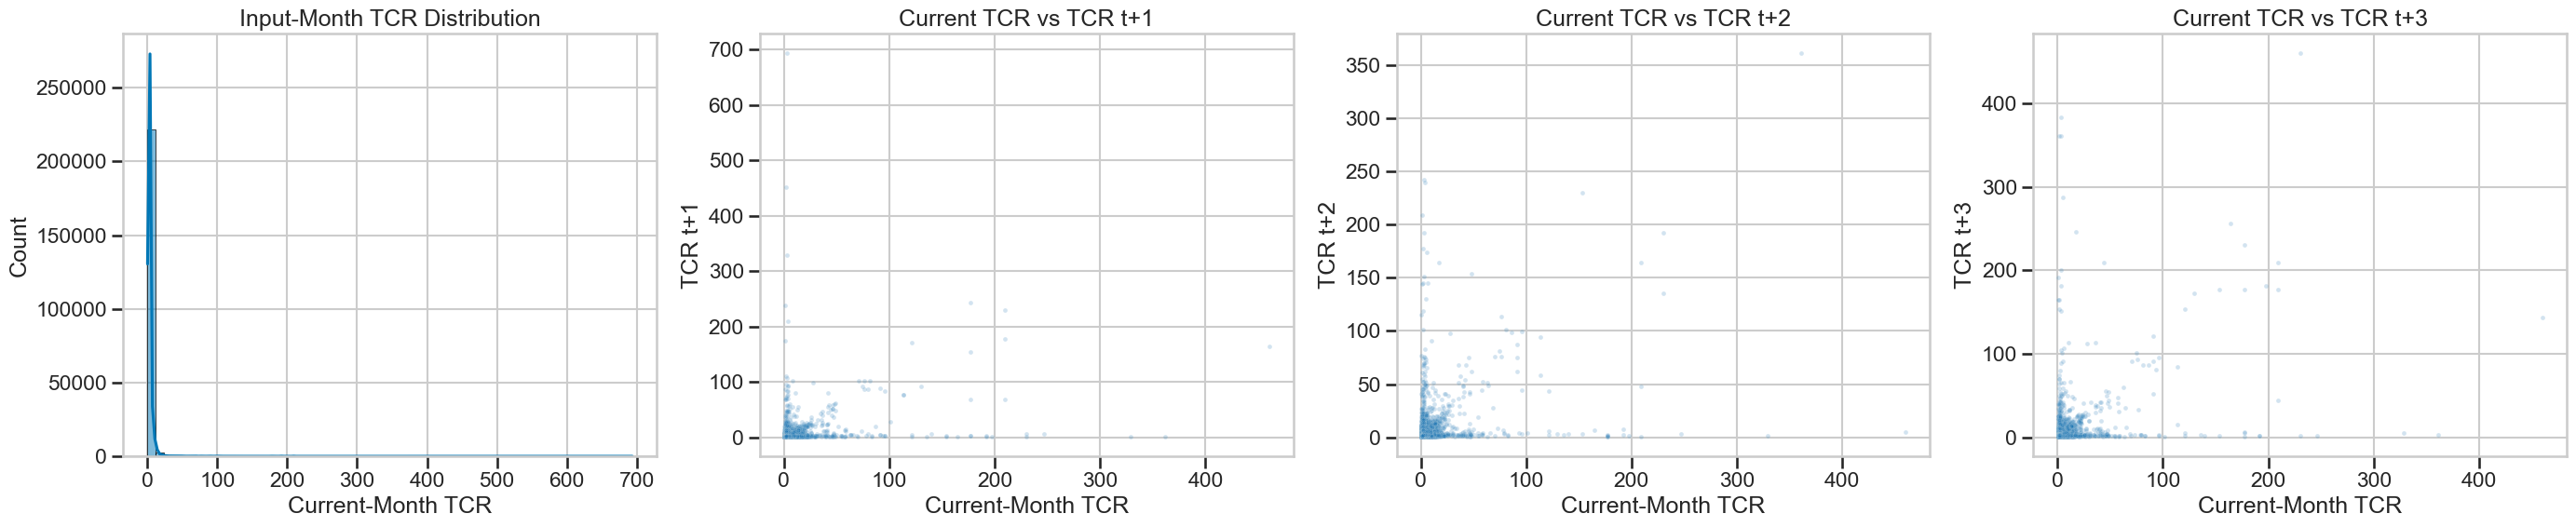

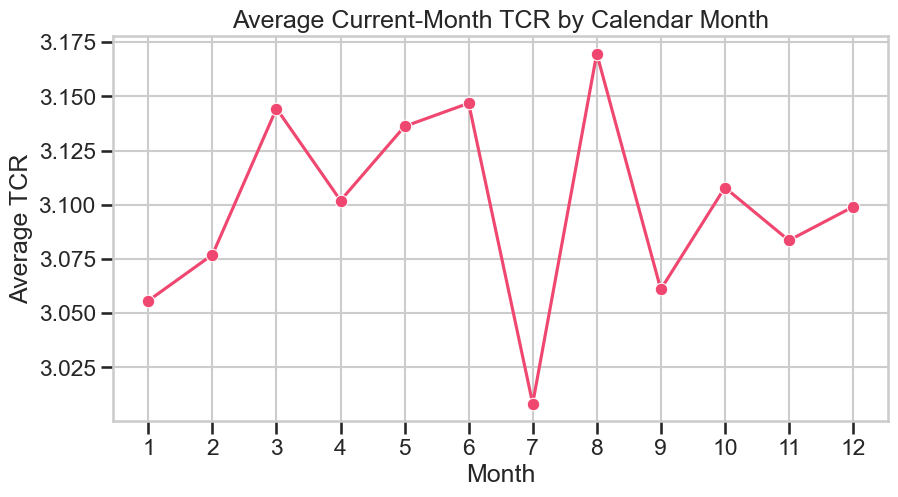

In [9]:
# EDA visualizations
fig, axes = plt.subplots(1, 4, figsize=(28, 6))

sns.histplot(supervised[TARGET_COL], bins=60, kde=True, ax=axes[0], color="#0077b6")
axes[0].set_title("Input-Month TCR Distribution")
axes[0].set_xlabel("Current-Month TCR")

sample_for_scatter = supervised.sample(min(30000, len(supervised)), random_state=RANDOM_STATE)
for i, h in enumerate(HORIZONS, start=1):
    sns.scatterplot(
        data=sample_for_scatter,
        x=TARGET_COL,
        y=f"target_tcr_t_plus_{h}",
        alpha=0.2,
        s=12,
        ax=axes[i],
    )
    axes[i].set_title(f"Current TCR vs TCR t+{h}")
    axes[i].set_xlabel("Current-Month TCR")
    axes[i].set_ylabel(f"TCR t+{h}")

plt.tight_layout()
plt.show()

monthly_profile = (
    supervised.groupby("month")[TARGET_COL]
    .mean()
    .reindex(range(1, 13))
)

plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_profile.index, y=monthly_profile.values, marker="o", color="#ef476f")
plt.title("Average Current-Month TCR by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Average TCR")
plt.xticks(range(1, 13))
plt.show()

## 5) Build Train-Test Split (Strict Leakage-Safe)
This split enforces two hard constraints:
- **No temporal leakage in labels**: training input month must be `<= 2018-09`, so all training targets (`t+1..t+3`) are in 2018 or earlier.
- **No merchant leakage**: test merchants are fully held out from training (merchant-disjoint split).

Definition used:
- **Test merchants**: merchants with valid 2019 input rows.
- **Test rows**: only 2019 input months for those held-out test merchants.
- **Train rows**: only non-test merchants with input month `<= 2018-09`.

In [24]:
# Define feature set and strict leakage-safe split
exclude_cols = {MERCHANT_COL, DATE_COL, *target_cols}
feature_cols = [c for c in supervised.columns if c not in exclude_cols]

# Merchants with valid 2019 entries are reserved for test only
test_merchants_set = set(
    supervised.loc[supervised[DATE_COL].dt.year.eq(2019), MERCHANT_COL].unique()
)

SAFE_TRAIN_CUTOFF = pd.Timestamp("2018-09-01")

is_test = supervised[MERCHANT_COL].isin(test_merchants_set) & supervised[DATE_COL].dt.year.eq(2019)
is_train = (~supervised[MERCHANT_COL].isin(test_merchants_set)) & (supervised[DATE_COL] <= SAFE_TRAIN_CUTOFF)

X = supervised[feature_cols].copy()
y = supervised[target_cols].copy()

X_train, X_test = X.loc[is_train], X.loc[is_test]
y_train, y_test = y.loc[is_train], y.loc[is_test]

train_merchants_set = set(supervised.loc[is_train, MERCHANT_COL].unique())
actual_test_merchants_set = set(supervised.loc[is_test, MERCHANT_COL].unique())
merchant_overlap = train_merchants_set.intersection(actual_test_merchants_set)

print("Strict split summary")
print(f"Train rows: {len(X_train):,} | Test rows: {len(X_test):,}")
print(f"Train merchants: {len(train_merchants_set):,} | Test merchants: {len(actual_test_merchants_set):,}")
print(f"Merchant overlap (train ∩ test): {len(merchant_overlap):,}")
print(f"Feature count: {len(feature_cols)}")

if len(X_test) == 0:
    raise ValueError("No valid test rows found under strict leakage-safe split.")
if len(X_train) == 0:
    raise ValueError("No valid train rows found under strict leakage-safe split.")
if len(merchant_overlap) > 0:
    raise ValueError("Merchant leakage detected: train and test merchants overlap.")

test_months = supervised.loc[is_test, DATE_COL].dt.to_period("M").astype(str)
train_months = supervised.loc[is_train, DATE_COL].dt.to_period("M").astype(str)
print("Train input month range:", f"{train_months.min()} to {train_months.max()}")
print("Test input month range:", f"{test_months.min()} to {test_months.max()}")

Strict split summary
Train rows: 23,999 | Test rows: 12,148
Train merchants: 3,914 | Test merchants: 2,096
Merchant overlap (train ∩ test): 0
Feature count: 43
Train input month range: 2010-01 to 2018-09
Test input month range: 2019-01 to 2019-07


## 6) Baseline Benchmark
Baseline policy: use the **current-month TCR** as the prediction for each of the next 3 months.

This is the minimum standard every model must beat to justify deployment complexity.

In [25]:
def regression_metrics(y_true, y_pred, horizon_names):
    rows = []
    for idx, h_name in enumerate(horizon_names):
        yt = y_true[:, idx]
        yp = y_pred[:, idx]
        rows.append({
            "horizon": h_name,
            "MAE": mean_absolute_error(yt, yp),
            "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
            "R2": r2_score(yt, yp),
        })
    out = pd.DataFrame(rows)
    out.loc[len(out)] = {
        "horizon": "overall_mean",
        "MAE": out["MAE"].mean(),
        "RMSE": out["RMSE"].mean(),
        "R2": out["R2"].mean(),
    }
    return out

horizon_names = [f"t+{h}" for h in HORIZONS]

baseline_pred = np.column_stack([X_test[TARGET_COL].values] * 3)
baseline_metrics = regression_metrics(y_test.values, baseline_pred, horizon_names)

print("Baseline metrics (predict next 3 months as current-month TCR):")
baseline_metrics

Baseline metrics (predict next 3 months as current-month TCR):


,horizon,MAE,RMSE,R2
0,t+1,1.483494,10.532194,-0.459377
1,t+2,1.482803,9.270522,-0.925369
2,t+3,1.445533,8.982966,-0.793905
3,overall_mean,1.470610,9.595227,-0.726217


## 7) Train and Tune Tree-Based Model Family
Models evaluated:
- Decision Tree
- Random Forest
- Extra Trees
- Gradient Boosting
- XGBoost

Tuning protocol:
- Use `RandomizedSearchCV` on the **training set only**.
- Use `GroupKFold` by `merchant_id` inside training to avoid leakage across CV folds.
- Optimize for negative MAE.
- Refit best hyperparameters, then evaluate on the strict leakage-safe test set.

In [27]:
# Train + tune model zoo with leakage-safe CV on training set only
from sklearn.model_selection import GroupKFold, RandomizedSearchCV

train_groups = supervised.loc[is_train, MERCHANT_COL]
cv = GroupKFold(n_splits=3)

models_to_tune = {
    "DecisionTree": {
        "estimator": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "params": {
            "max_depth": [4, 6, 8, 10, 12, None],
            "min_samples_split": [2, 5, 10, 20, 50],
            "min_samples_leaf": [1, 5, 10, 20, 50, 100],
            "max_features": [None, "sqrt", "log2"],
        },
        "n_iter": 16,
    },
    "RandomForest": {
        "estimator": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "params": {
            "n_estimators": [200, 300, 500],
            "max_depth": [8, 12, 16, None],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 5, 10, 20, 50],
            "max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
        },
        "n_iter": 16,
    },
    "ExtraTrees": {
        "estimator": ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "params": {
            "n_estimators": [200, 300, 500],
            "max_depth": [8, 12, 16, None],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 5, 10, 20, 50],
            "max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
        },
        "n_iter": 16,
    },
    "GradientBoosting": {
        "estimator": MultiOutputRegressor(
            GradientBoostingRegressor(random_state=RANDOM_STATE)
        ),
        "params": {
            "estimator__n_estimators": [100, 200, 300, 500],
            "estimator__learning_rate": [0.01, 0.03, 0.05, 0.1],
            "estimator__max_depth": [2, 3, 4, 5],
            "estimator__min_samples_split": [2, 5, 10, 20],
            "estimator__min_samples_leaf": [1, 5, 10, 20],
            "estimator__subsample": [0.6, 0.8, 1.0],
        },
        "n_iter": 16,
    },
}

try:
    from xgboost import XGBRegressor

    models_to_tune["XGBoost"] = {
        "estimator": MultiOutputRegressor(
            XGBRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                objective="reg:squarederror",
            )
        ),
        "params": {
            "estimator__n_estimators": [200, 300, 500],
            "estimator__max_depth": [3, 5, 7, 9],
            "estimator__learning_rate": [0.01, 0.03, 0.05, 0.1],
            "estimator__subsample": [0.6, 0.8, 1.0],
            "estimator__colsample_bytree": [0.6, 0.8, 1.0],
            "estimator__reg_lambda": [0.5, 1.0, 2.0, 5.0],
        },
        "n_iter": 16,
    }
    xgb_available = True
except Exception as exc:
    xgb_available = False
    print("XGBoost unavailable and will be skipped.", exc)

models = {}
model_predictions = {}
model_metrics = []
tuning_rows = []

for name, cfg in models_to_tune.items():
    print(f"Tuning {name}...")

    search = RandomizedSearchCV(
        estimator=cfg["estimator"],
        param_distributions=cfg["params"],
        n_iter=cfg["n_iter"],
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        cv=cv,
        refit=True,
        random_state=RANDOM_STATE,
        verbose=0,
    )

    search.fit(X_train, y_train, groups=train_groups)
    best_model = search.best_estimator_

    models[name] = best_model
    pred = best_model.predict(X_test)
    model_predictions[name] = pred

    scores = regression_metrics(y_test.values, pred, horizon_names)
    overall = scores[scores["horizon"] == "overall_mean"].iloc[0]

    model_metrics.append({
        "model": name,
        "overall_MAE": overall["MAE"],
        "overall_RMSE": overall["RMSE"],
        "overall_R2": overall["R2"],
    })

    tuning_rows.append({
        "model": name,
        "cv_best_neg_MAE": search.best_score_,
        "cv_best_MAE": -search.best_score_,
        "best_params": search.best_params_,
    })

metrics_df = pd.DataFrame(model_metrics).sort_values("overall_MAE").reset_index(drop=True)
tuning_summary = pd.DataFrame(tuning_rows).sort_values("cv_best_MAE").reset_index(drop=True)

baseline_overall = baseline_metrics.loc[baseline_metrics["horizon"] == "overall_mean"].iloc[0]
baseline_row = pd.DataFrame([{
    "model": "Baseline_current_TCR",
    "overall_MAE": baseline_overall["MAE"],
    "overall_RMSE": baseline_overall["RMSE"],
    "overall_R2": baseline_overall["R2"],
}])

leaderboard = pd.concat([baseline_row, metrics_df], ignore_index=True).sort_values("overall_MAE")

print("\nHyperparameter tuning summary (best CV MAE):")
display(tuning_summary)

print("\nTest-set leaderboard after tuning:")
leaderboard

Tuning DecisionTree...
Tuning RandomForest...


/Users/denzel/Documents/GitHub/404_found_us/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/denzel/Documents/GitHub/404_found_us/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/denzel/Documents/GitHub/404_found_us/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warning

Tuning ExtraTrees...


/Users/denzel/Documents/GitHub/404_found_us/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/denzel/Documents/GitHub/404_found_us/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/denzel/Documents/GitHub/404_found_us/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warning

Tuning GradientBoosting...
Tuning XGBoost...

Hyperparameter tuning summary (best CV MAE):


,model,cv_best_neg_MAE,cv_best_MAE,best_params
0,ExtraTrees,-2.206096,2.206096,"{'n_estimators': 200, 'min_samples_split': 5, ..."
1,RandomForest,-2.206952,2.206952,"{'n_estimators': 200, 'min_samples_split': 5, ..."
2,GradientBoosting,-2.226880,2.226880,"{'estimator__subsample': 1.0, 'estimator__n_es..."
3,DecisionTree,-2.243509,2.243509,"{'min_samples_split': 10, 'min_samples_leaf': ..."
4,XGBoost,-2.250250,2.250250,"{'estimator__subsample': 0.6, 'estimator__reg_..."



Test-set leaderboard after tuning:


,model,overall_MAE,overall_RMSE,overall_R2
0,Baseline_current_TCR,1.470610,9.595227,-0.726217
1,RandomForest,2.021672,7.309950,0.015355
2,ExtraTrees,2.032782,7.344834,0.006111
3,DecisionTree,2.050543,7.312735,0.014703
4,GradientBoosting,2.070695,7.291567,0.017573
5,XGBoost,2.218685,7.440577,-0.023887


In [28]:
# Per-horizon performance table (including baseline)
per_horizon_rows = []

base_scores = baseline_metrics[baseline_metrics["horizon"] != "overall_mean"].copy()
for _, row in base_scores.iterrows():
    per_horizon_rows.append({
        "model": "Baseline_current_TCR",
        "horizon": row["horizon"],
        "MAE": row["MAE"],
        "RMSE": row["RMSE"],
        "R2": row["R2"],
    })

for model_name, pred in model_predictions.items():
    scores = regression_metrics(y_test.values, pred, horizon_names)
    scores = scores[scores["horizon"] != "overall_mean"]
    for _, row in scores.iterrows():
        per_horizon_rows.append({
            "model": model_name,
            "horizon": row["horizon"],
            "MAE": row["MAE"],
            "RMSE": row["RMSE"],
            "R2": row["R2"],
        })

per_horizon_df = pd.DataFrame(per_horizon_rows)
per_horizon_df.sort_values(["horizon", "MAE"]).head(15)

,model,horizon,MAE,RMSE,R2
0,Baseline_current_TCR,t+1,1.483494,10.532194,-0.459377
6,RandomForest,t+1,1.991206,8.625136,0.021273
12,GradientBoosting,t+1,1.992216,8.492043,0.051245
9,ExtraTrees,t+1,2.048486,8.673857,0.010184
3,DecisionTree,t+1,2.114453,8.632642,0.019569
15,XGBoost,t+1,2.204960,8.629412,0.020302
1,Baseline_current_TCR,t+2,1.482803,9.270522,-0.925369
4,DecisionTree,t+2,1.987556,6.640525,0.012106
10,ExtraTrees,t+2,2.020913,6.670629,0.003129
7,RandomForest,t+2,2.021500,6.640323,0.012166


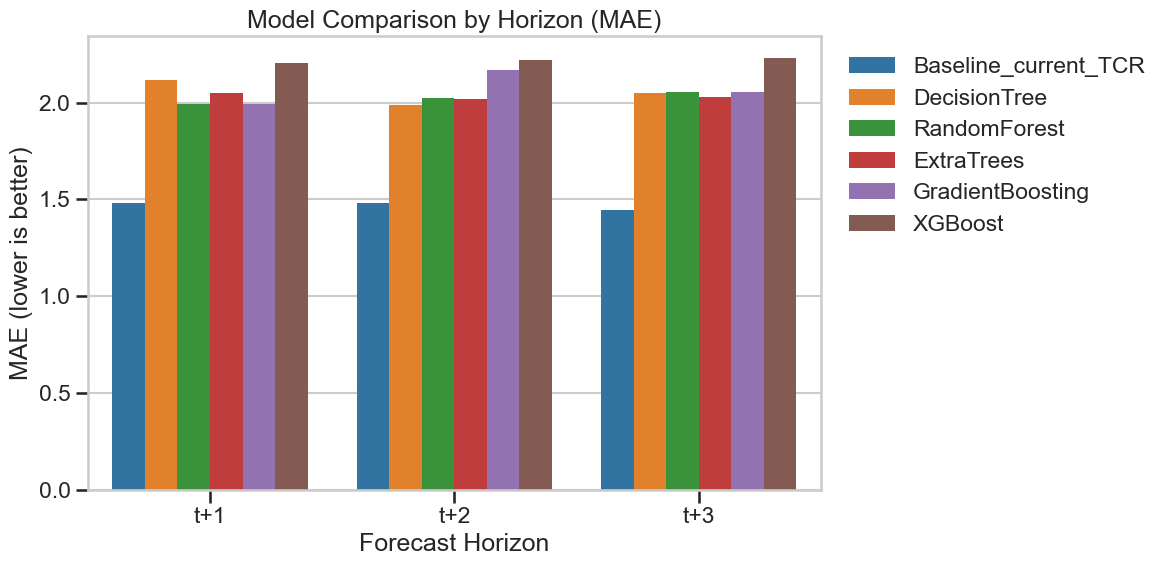

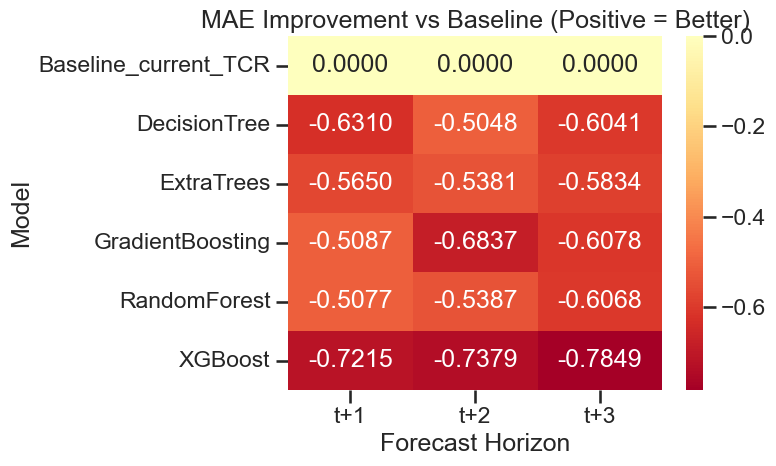

horizon,t+1,t+2,t+3
model,,,
Baseline_current_TCR,0.000000,0.000000,0.000000
DecisionTree,-0.630958,-0.504752,-0.604087
ExtraTrees,-0.564992,-0.538110,-0.583414
GradientBoosting,-0.508721,-0.683689,-0.607843
RandomForest,-0.507712,-0.538696,-0.606778
XGBoost,-0.721466,-0.737899,-0.784859


In [29]:
# Visual comparison: MAE by horizon (lower is better)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=per_horizon_df,
    x="horizon",
    y="MAE",
    hue="model",
    errorbar=None,
)
plt.title("Model Comparison by Horizon (MAE)")
plt.ylabel("MAE (lower is better)")
plt.xlabel("Forecast Horizon")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

# Improvement over baseline (positive means better than baseline)
pivot_mae = per_horizon_df.pivot(index="model", columns="horizon", values="MAE")
baseline_mae = pivot_mae.loc["Baseline_current_TCR"]
improvement = baseline_mae - pivot_mae

plt.figure(figsize=(8, 5))
sns.heatmap(improvement, annot=True, fmt=".4f", cmap="RdYlGn", center=0)
plt.title("MAE Improvement vs Baseline (Positive = Better)")
plt.xlabel("Forecast Horizon")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

improvement

## 8) Interpretation of Metrics
How to read the key metrics:
- **MAE**: average absolute error in TCR points. Lower is better and easiest to explain operationally.
- **RMSE**: penalizes larger misses more than MAE. Lower is better.
- **R²**: proportion of variance explained. Higher is better (can be negative if worse than naive mean prediction).

Decision focus:
- First verify that a model beats the one-month baseline across all horizons.
- Prefer models that are consistently strong on both MAE and RMSE, not just one metric.

Best model by overall MAE: RandomForest


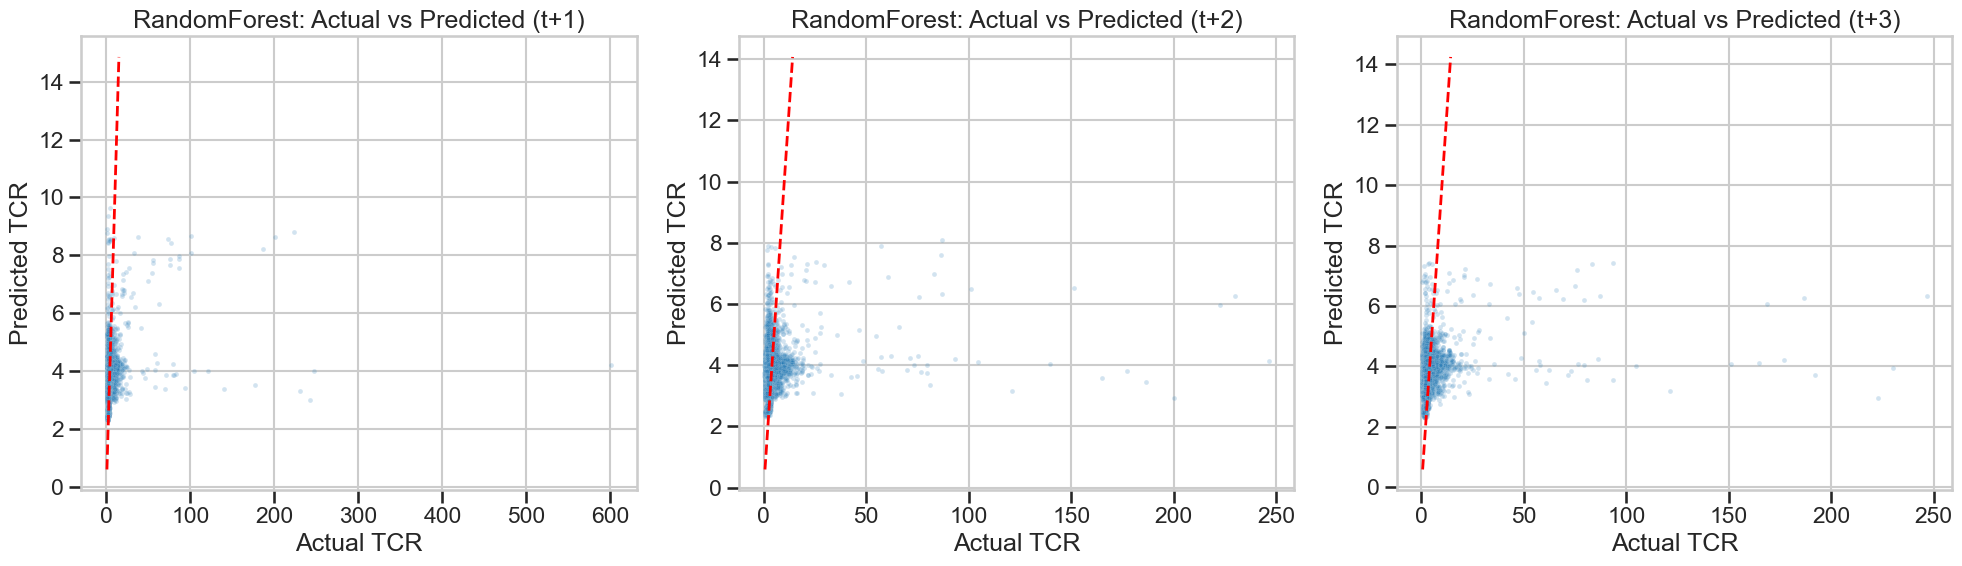

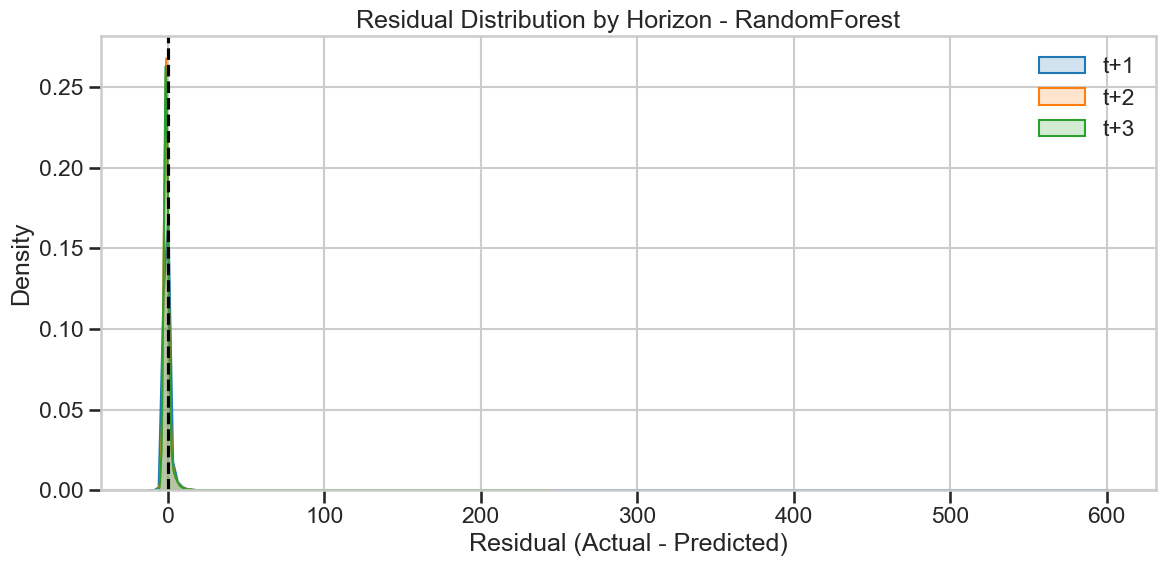

In [30]:
# Select best model by overall MAE (excluding baseline row)
model_only = leaderboard[leaderboard["model"] != "Baseline_current_TCR"].copy()
best_model_name = model_only.iloc[0]["model"]
best_pred = model_predictions[best_model_name]

print(f"Best model by overall MAE: {best_model_name}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, h in enumerate(HORIZONS):
    ax = axes[i]
    yt = y_test.iloc[:, i].values
    yp = best_pred[:, i]
    sns.scatterplot(x=yt, y=yp, alpha=0.2, s=12, ax=ax)
    min_v, max_v = np.nanpercentile(yt, 1), np.nanpercentile(yt, 99)
    ax.plot([min_v, max_v], [min_v, max_v], color="red", linestyle="--", linewidth=2)
    ax.set_title(f"{best_model_name}: Actual vs Predicted (t+{h})")
    ax.set_xlabel("Actual TCR")
    ax.set_ylabel("Predicted TCR")

plt.tight_layout()
plt.show()

# Residual distributions by horizon
residual_df = pd.DataFrame({
    f"t+{h}": y_test.iloc[:, i].values - best_pred[:, i]
    for i, h in enumerate(HORIZONS)
})

plt.figure(figsize=(12, 6))
for col in residual_df.columns:
    sns.kdeplot(residual_df[col], label=col, fill=True, alpha=0.2)
plt.axvline(0, color="black", linestyle="--")
plt.title(f"Residual Distribution by Horizon - {best_model_name}")
plt.xlabel("Residual (Actual - Predicted)")
plt.legend()
plt.tight_layout()
plt.show()

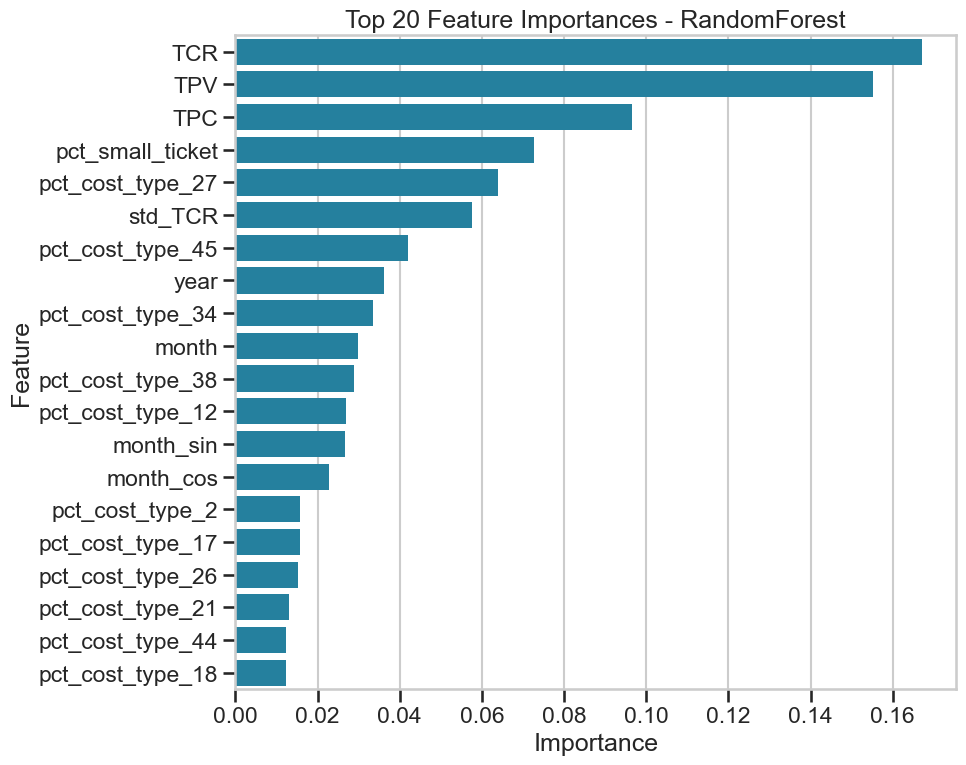

In [31]:
# Feature importance (for models that expose it directly)
def extract_importance(model):
    if hasattr(model, "feature_importances_"):
        return model.feature_importances_
    # For MultiOutputRegressor, average importances across horizon-specific estimators
    if hasattr(model, "estimators_") and len(model.estimators_) > 0:
        imps = [est.feature_importances_ for est in model.estimators_ if hasattr(est, "feature_importances_")]
        if imps:
            return np.mean(np.vstack(imps), axis=0)
    return None

best_model = models[best_model_name]
importance = extract_importance(best_model)

if importance is not None:
    fi = (
        pd.DataFrame({"feature": feature_cols, "importance": importance})
        .sort_values("importance", ascending=False)
        .head(20)
    )

    plt.figure(figsize=(10, 8))
    sns.barplot(data=fi, x="importance", y="feature", orient="h", color="#118ab2")
    plt.title(f"Top 20 Feature Importances - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    fi.head(10)
else:
    print(f"Feature importance is not directly available for {best_model_name}.")

In [32]:
# Auto-generated conclusion summary from observed metrics
best_overall_mae = model_only.iloc[0]["overall_MAE"]
baseline_overall_mae = baseline_row.iloc[0]["overall_MAE"]
improvement_pct = 100 * (baseline_overall_mae - best_overall_mae) / baseline_overall_mae

print("Conclusion Summary")
print("-" * 80)
print(f"Best model: {best_model_name}")
print(f"Baseline overall MAE: {baseline_overall_mae:.4f}")
print(f"Best-model overall MAE: {best_overall_mae:.4f}")
print(f"Relative MAE improvement vs baseline: {improvement_pct:.2f}%")

wins = (
    per_horizon_df
    .pivot(index="model", columns="horizon", values="MAE")
    .sub(pivot_mae.loc["Baseline_current_TCR"], axis=1)
    .loc[best_model_name]
)

print("\nBest model MAE delta vs baseline by horizon (negative is better):")
for h, delta in wins.items():
    print(f"  {h}: {delta:.4f}")

Conclusion Summary
--------------------------------------------------------------------------------
Best model: RandomForest
Baseline overall MAE: 1.4706
Best-model overall MAE: 2.0217
Relative MAE improvement vs baseline: -37.47%

Best model MAE delta vs baseline by horizon (negative is better):
  t+1: 0.5077
  t+2: 0.5387
  t+3: 0.6068


## 9) Final Notes and Deployment Guidance
- If the best model only marginally beats baseline, prefer baseline due to simplicity and stability.
- If tree ensembles materially beat baseline across all horizons, they are suitable candidates for deployment.
- In production, monitor drift in input-month feature distributions and TCR error by horizon (`t+1`, `t+2`, `t+3`) separately.
- Re-train periodically with latest merchant-month history to preserve performance.

## 10) Test-Set Merchant Timeline Visualizations (10 Merchants)
This section focuses strictly on the **test set (2019 input months)**.

Approach:
- Use 10 test merchants and one concrete input row per merchant.
- Show the exact input month `t` and forecast months `t+1..t+3`.
- Overlay **baseline** and **all trained tree models** against actual TCR on the same timeline.

Selected 10 test merchants for explicit t vs forecast plots:
[22, 57580, 58285, 58168, 58141, 58125, 57909, 57889, 57885, 57758]


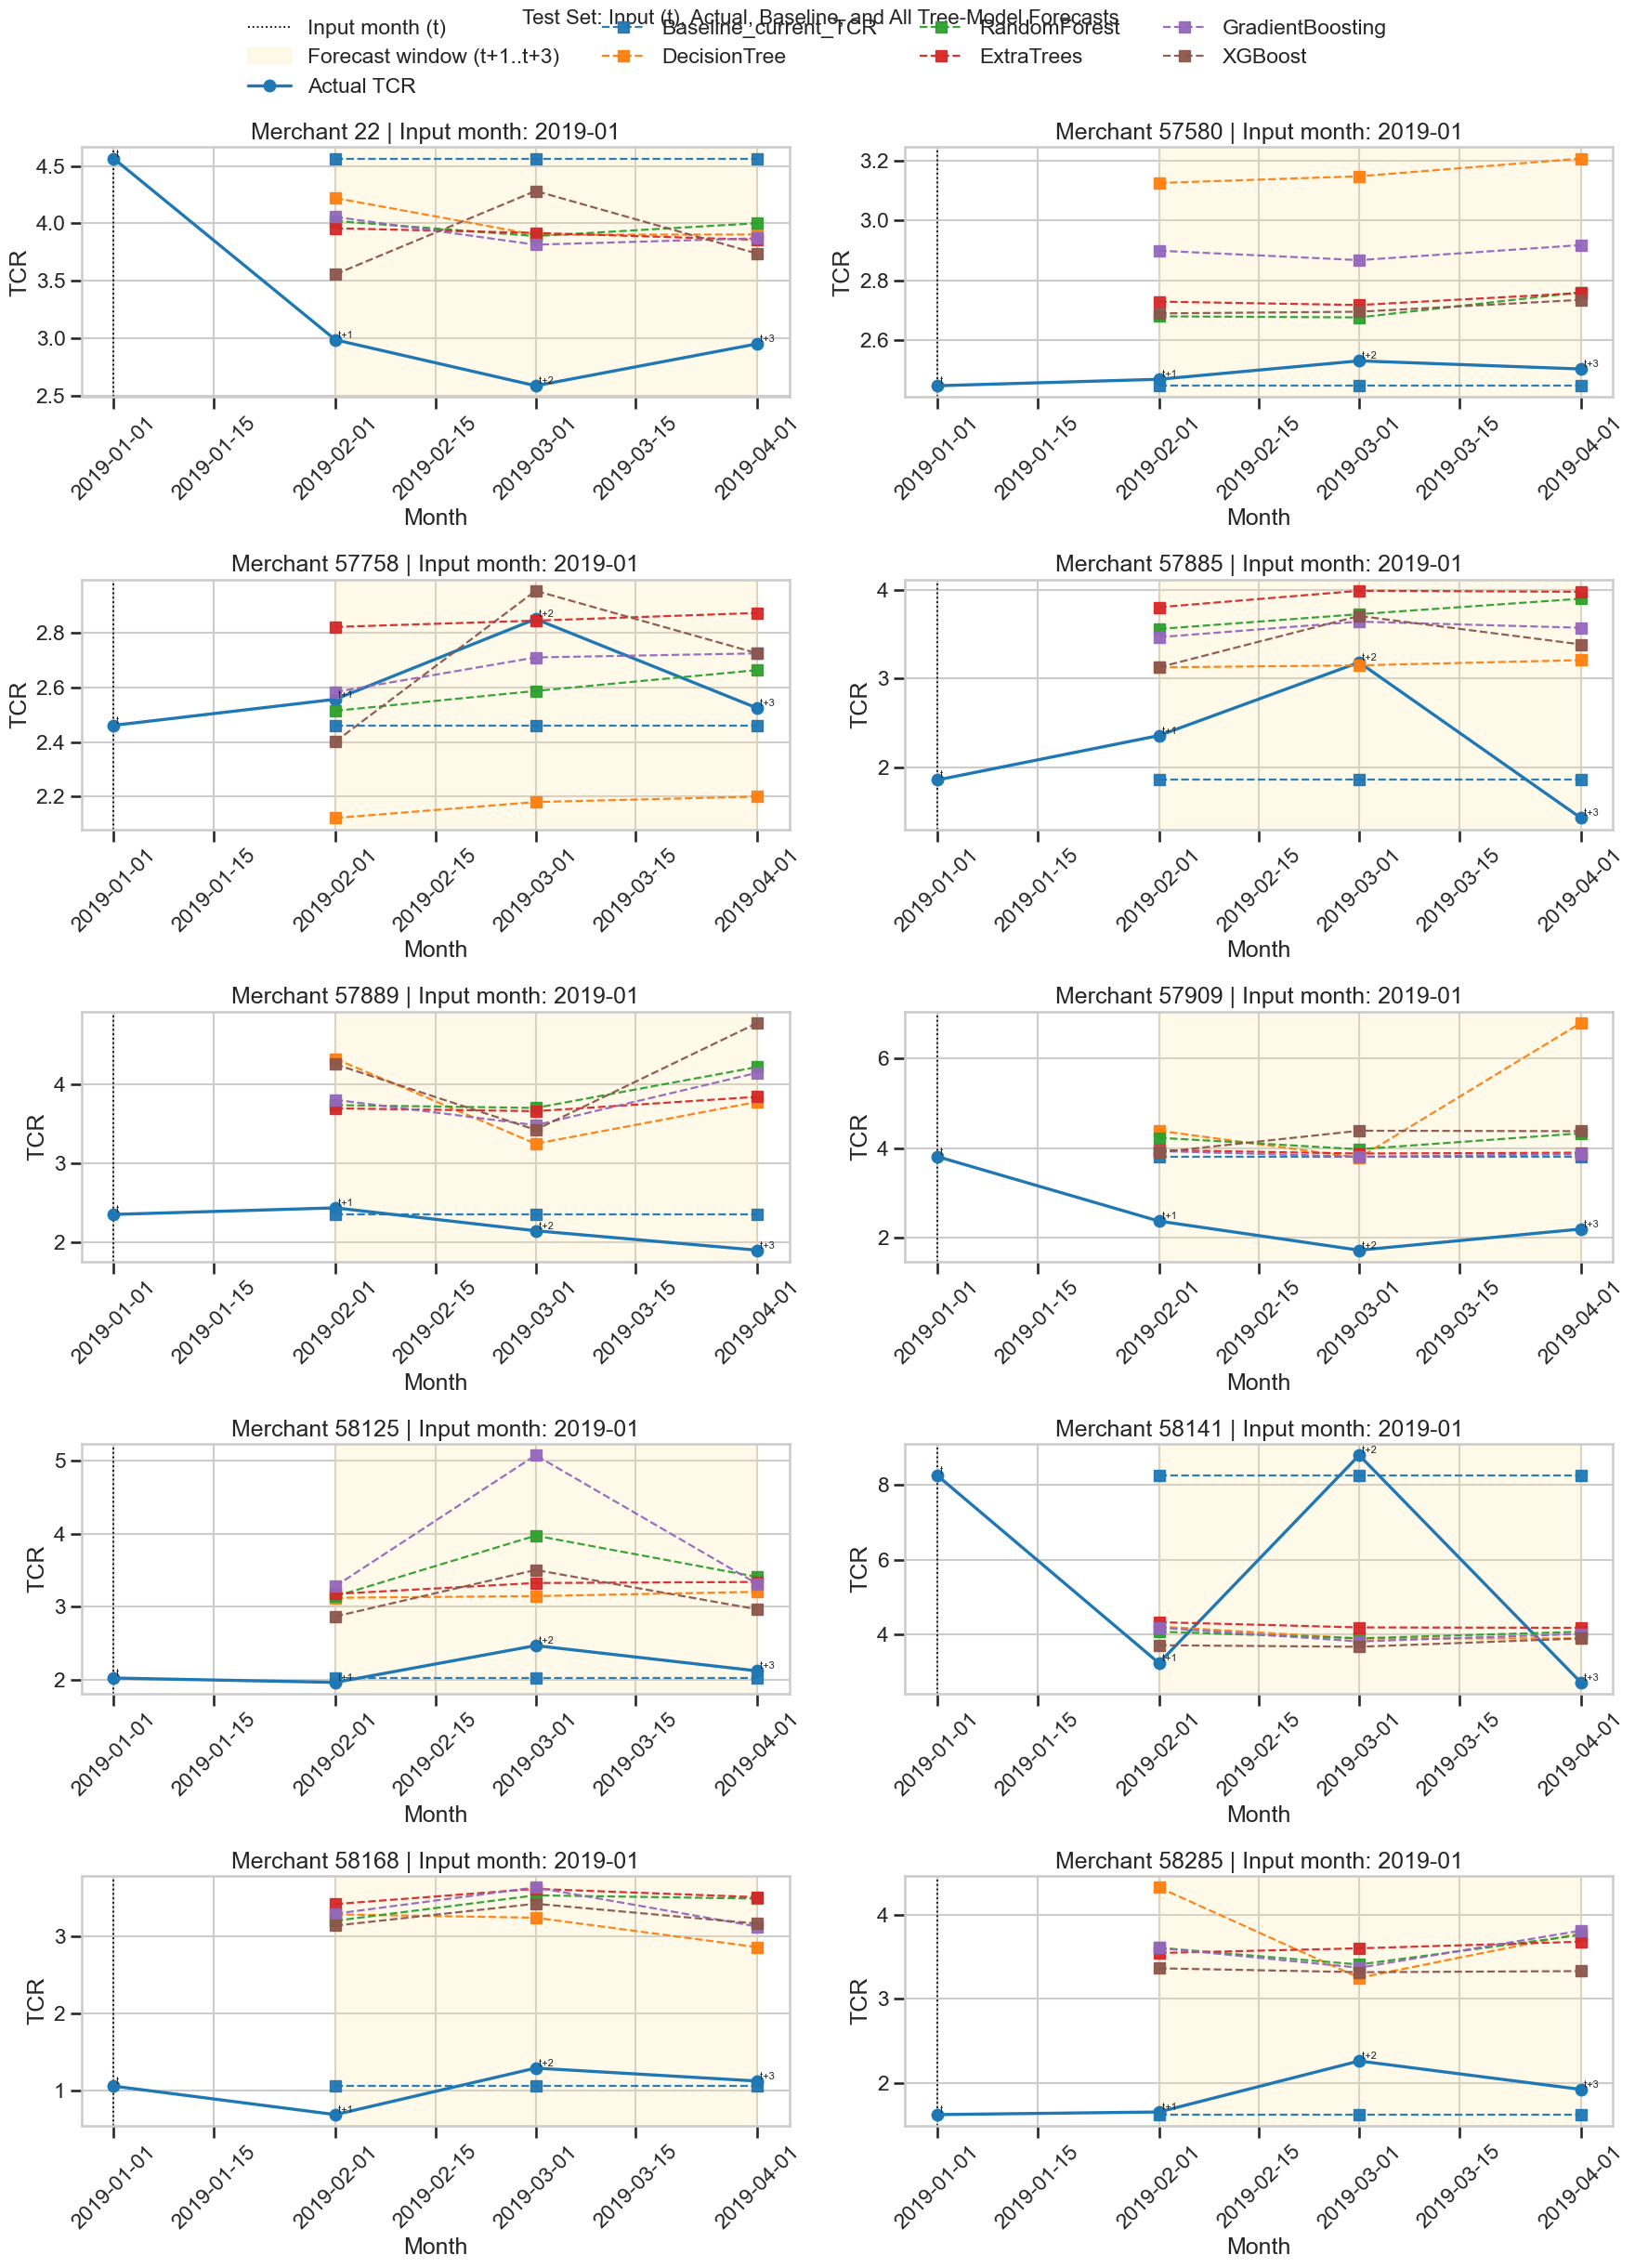

,merchant_id,year_month,input_tcr_t,actual_t_plus_1,actual_t_plus_2,actual_t_plus_3,Baseline_current_TCR_pred_t_plus_1,Baseline_current_TCR_pred_t_plus_2,Baseline_current_TCR_pred_t_plus_3,DecisionTree_pred_t_plus_1,...,RandomForest_pred_t_plus_3,ExtraTrees_pred_t_plus_1,ExtraTrees_pred_t_plus_2,ExtraTrees_pred_t_plus_3,GradientBoosting_pred_t_plus_1,GradientBoosting_pred_t_plus_2,GradientBoosting_pred_t_plus_3,XGBoost_pred_t_plus_1,XGBoost_pred_t_plus_2,XGBoost_pred_t_plus_3
0,22,2019-01-01,4.5659,2.9846,2.5841,2.9498,4.5659,4.5659,4.5659,4.221891,...,4.001956,3.957678,3.917134,3.857245,4.057031,3.814683,3.870290,3.556766,4.283356,3.736614
1,57580,2019-01-01,2.4488,2.4704,2.5319,2.5047,2.4488,2.4488,2.4488,3.125150,...,2.760760,2.729478,2.718142,2.758147,2.899382,2.867859,2.918035,2.690207,2.695789,2.735311
2,57758,2019-01-01,2.4609,2.5566,2.8509,2.5240,2.4609,2.4609,2.4609,2.121149,...,2.663579,2.821861,2.845046,2.873165,2.583424,2.710083,2.724892,2.401333,2.954579,2.725252
3,57885,2019-01-01,1.8587,2.3580,3.1813,1.4313,1.8587,1.8587,1.8587,3.125150,...,3.897347,3.801569,3.986639,3.975538,3.464792,3.639644,3.570569,3.125726,3.703232,3.383367
4,57889,2019-01-01,2.3532,2.4362,2.1463,1.9005,2.3532,2.3532,2.3532,4.323619,...,4.219517,3.695932,3.660599,3.842090,3.804194,3.482760,4.146796,4.254042,3.424559,4.777015
5,57909,2019-01-01,3.8167,2.3774,1.7293,2.2007,3.8167,3.8167,3.8167,4.393968,...,4.336183,3.960802,3.885195,3.903944,3.940380,3.814683,3.870290,3.912778,4.393929,4.383688
6,58125,2019-01-01,2.0245,1.9647,2.4693,2.1219,2.0245,2.0245,2.0245,3.125150,...,3.410379,3.177670,3.327379,3.341690,3.283286,5.079651,3.314794,2.868863,3.506186,2.966196
7,58141,2019-01-01,8.2527,3.2446,8.7942,2.7295,8.2527,8.2527,8.2527,4.221891,...,4.081515,4.336584,4.197163,4.185777,4.189206,3.822679,4.023374,3.720900,3.680692,3.902340
8,58168,2019-01-01,1.0631,0.6948,1.2964,1.1289,1.0631,1.0631,1.0631,3.284063,...,3.488188,3.417624,3.614505,3.506930,3.293055,3.633140,3.126670,3.139172,3.422037,3.164323
9,58285,2019-01-01,1.6206,1.6518,2.2585,1.9204,1.6206,1.6206,1.6206,4.323619,...,3.757558,3.543286,3.598865,3.677375,3.604044,3.368087,3.809501,3.361063,3.314991,3.327851


In [33]:
# Build explicit t vs t+1..t+3 timeline plots for 10 test merchants
# Includes baseline + all tuned tree models

test_rows = supervised.loc[is_test, [MERCHANT_COL, DATE_COL]].copy().reset_index(drop=True)
test_rows["input_tcr_t"] = X_test[TARGET_COL].reset_index(drop=True)

for i, h in enumerate(HORIZONS):
    test_rows[f"actual_t_plus_{h}"] = y_test.iloc[:, i].reset_index(drop=True)

# Baseline + all model predictions on test set
prediction_store = {"Baseline_current_TCR": baseline_pred}
prediction_store.update(model_predictions)

for model_name, pred_arr in prediction_store.items():
    for i, h in enumerate(HORIZONS):
        test_rows[f"{model_name}_pred_t_plus_{h}"] = pred_arr[:, i]

merchant_test_counts = test_rows.groupby(MERCHANT_COL)[DATE_COL].size().sort_values(ascending=False)
n_merchants = min(10, len(merchant_test_counts))
selected_merchants = merchant_test_counts.head(n_merchants).index.tolist()

selected_rows = (
    test_rows[test_rows[MERCHANT_COL].isin(selected_merchants)]
    .sort_values([MERCHANT_COL, DATE_COL])
    .groupby(MERCHANT_COL, as_index=False)
    .first()
)

print(f"Selected {n_merchants} test merchants for explicit t vs forecast plots:")
print(selected_merchants)

n_cols = 2
n_rows = int(np.ceil(n_merchants / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.8 * n_rows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

model_names = list(prediction_store.keys())
model_palette = dict(zip(model_names, sns.color_palette("tab10", n_colors=len(model_names))))

for idx, row in selected_rows.iterrows():
    ax = axes[idx]
    merchant = row[MERCHANT_COL]
    t_date = row[DATE_COL]

    x_dates = [t_date + pd.DateOffset(months=h) for h in [0, 1, 2, 3]]
    horizon_dates = x_dates[1:]
    step_labels = ["t", "t+1", "t+2", "t+3"]

    actual_series = [
        row["input_tcr_t"],
        row["actual_t_plus_1"],
        row["actual_t_plus_2"],
        row["actual_t_plus_3"],
    ]

    # Explicitly mark input and forecast windows
    ax.axvline(x_dates[0], color="black", linestyle=":", linewidth=1.3, label="Input month (t)")
    ax.axvspan(x_dates[1], x_dates[3], color="#ffe8a1", alpha=0.22, label="Forecast window (t+1..t+3)")

    ax.plot(x_dates, actual_series, marker="o", linewidth=2.4, color="#1f77b4", label="Actual TCR")

    # Plot baseline + all trained tree models over t+1..t+3
    for model_name in model_names:
        pred_series = [
            row[f"{model_name}_pred_t_plus_1"],
            row[f"{model_name}_pred_t_plus_2"],
            row[f"{model_name}_pred_t_plus_3"],
        ]
        ax.plot(
            horizon_dates,
            pred_series,
            marker="s",
            linewidth=1.6,
            linestyle="--",
            color=model_palette[model_name],
            alpha=0.95,
            label=model_name,
        )

    for x, y, lbl in zip(x_dates, actual_series, step_labels):
        if pd.notna(y):
            ax.text(x, y, f" {lbl}", fontsize=8, va="bottom")

    ax.set_title(f"Merchant {merchant} | Input month: {t_date.strftime('%Y-%m')}")
    ax.set_xlabel("Month")
    ax.set_ylabel("TCR")
    ax.tick_params(axis="x", rotation=45)

for j in range(n_merchants, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc="upper center", ncol=4, frameon=False)
fig.suptitle("Test Set: Input (t), Actual, Baseline, and All Tree-Model Forecasts", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

selected_cols = [MERCHANT_COL, DATE_COL, "input_tcr_t", "actual_t_plus_1", "actual_t_plus_2", "actual_t_plus_3"]
for model_name in model_names:
    selected_cols.extend([
        f"{model_name}_pred_t_plus_1",
        f"{model_name}_pred_t_plus_2",
        f"{model_name}_pred_t_plus_3",
    ])

selected_rows[selected_cols].head(10)

## 11) Train-Test Leakage Audit
Audit checks requested:
- Did training rows use any target values that belong to 2019 test-period months?
- Are test merchants fully disjoint from train merchants?

This section reports those checks explicitly.

In [34]:
# Leakage audit for the active split
from IPython.display import display

split_audit = supervised[[MERCHANT_COL, DATE_COL] + target_cols].copy()

# Use the active split masks already defined in Cell 10
train_mask_active = is_train.copy()
test_mask_active = is_test.copy()

for h in HORIZONS:
    split_audit[f"target_month_t_plus_{h}"] = split_audit[DATE_COL] + pd.DateOffset(months=h)

train_rows = split_audit.loc[train_mask_active].copy()

# Temporal leakage check: any training label month in 2019 or later?
train_uses_future_targets = {}
for h in HORIZONS:
    col = f"target_month_t_plus_{h}"
    train_uses_future_targets[h] = int((train_rows[col].dt.year >= 2019).sum())

train_merchants_set = set(split_audit.loc[train_mask_active, MERCHANT_COL].unique())
test_merchants_set = set(split_audit.loc[test_mask_active, MERCHANT_COL].unique())
overlap_merchants = train_merchants_set.intersection(test_merchants_set)

audit_summary = pd.DataFrame([
    {"metric": "Train rows (active split)", "value": int(train_mask_active.sum())},
    {"metric": "Test rows (active split)", "value": int(test_mask_active.sum())},
    {"metric": "Train merchants", "value": len(train_merchants_set)},
    {"metric": "Test merchants", "value": len(test_merchants_set)},
    {"metric": "Merchant overlap (train ∩ test)", "value": len(overlap_merchants)},
    {"metric": "Training labels with target month >= 2019 (t+1)", "value": train_uses_future_targets[1]},
    {"metric": "Training labels with target month >= 2019 (t+2)", "value": train_uses_future_targets[2]},
    {"metric": "Training labels with target month >= 2019 (t+3)", "value": train_uses_future_targets[3]},
])

print("Leakage audit under active split:")
display(audit_summary)

temporal_leak_free = sum(train_uses_future_targets.values()) == 0
merchant_leak_free = len(overlap_merchants) == 0

print("\nDirect answers:")
print(f"- Included 2019+ months in training targets: {not temporal_leak_free}")
print(f"- Test merchants strictly disjoint from train: {merchant_leak_free}")
print(f"- Strict leakage-safe status: {temporal_leak_free and merchant_leak_free}")

Leakage audit under active split:


,metric,value
0,Train rows (active split),23999
1,Test rows (active split),12148
2,Train merchants,3914
3,Test merchants,2096
4,Merchant overlap (train ∩ test),0
5,Training labels with target month >= 2019 (t+1),0
6,Training labels with target month >= 2019 (t+2),0
7,Training labels with target month >= 2019 (t+3),0



Direct answers:
- Included 2019+ months in training targets: False
- Test merchants strictly disjoint from train: True
- Strict leakage-safe status: True


## 12) Method 1 - Delta Target Modeling (`y_{t+h} - y_t`)
Idea:
- Predict change from current-month TCR instead of absolute future TCR.
- Reconstruct absolute forecasts as `y_t + predicted_delta`.

Goal:
- Test whether explicit level anchoring improves over direct tree regression.

In [35]:
# Method 1: Delta target modeling with RandomForest

y_delta_train = y_train.sub(X_train[TARGET_COL], axis=0)
y_delta_test = y_test.sub(X_test[TARGET_COL], axis=0)

rf_delta = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_delta.fit(X_train, y_delta_train)

delta_pred = rf_delta.predict(X_test)
rf_delta_abs_pred = delta_pred + np.column_stack([X_test[TARGET_COL].values] * 3)

method1_scores = regression_metrics(y_test.values, rf_delta_abs_pred, horizon_names)
method1_overall = method1_scores.loc[method1_scores["horizon"] == "overall_mean"].iloc[0]

method1_summary = pd.DataFrame([
    {"strategy": "Baseline_current_TCR", "overall_MAE": baseline_overall["MAE"], "overall_RMSE": baseline_overall["RMSE"], "overall_R2": baseline_overall["R2"]},
    {"strategy": "Method1_Delta_RF", "overall_MAE": method1_overall["MAE"], "overall_RMSE": method1_overall["RMSE"], "overall_R2": method1_overall["R2"]},
]).sort_values("overall_MAE")

print("Method 1 result (lower MAE is better):")
method1_summary

Method 1 result (lower MAE is better):


,strategy,overall_MAE,overall_RMSE,overall_R2
0,Baseline_current_TCR,1.470610,9.595227,-0.726217
1,Method1_Delta_RF,2.102646,8.205721,-0.248283


## 13) Method 2 - Horizon-Specific Models
Idea:
- Train a separate model for each horizon (`t+1`, `t+2`, `t+3`) rather than one shared multi-output fit.

Goal:
- Allow each horizon to have its own bias-variance tradeoff and hyperparameters.

In [36]:
# Method 2: Horizon-specific tuned RandomForest models
from sklearn.model_selection import RandomizedSearchCV

horizon_models = {}
horizon_pred = np.zeros_like(y_test.values, dtype=float)
method2_tuning = []

h2_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [8, 12, 16, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.8, 1.0],
}

for i, h in enumerate(HORIZONS):
    rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    rs = RandomizedSearchCV(
        estimator=rf,
        param_distributions=h2_param_grid,
        n_iter=12,
        scoring="neg_mean_absolute_error",
        cv=3,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
    )
    rs.fit(X_train, y_train.iloc[:, i])
    horizon_models[h] = rs.best_estimator_
    horizon_pred[:, i] = rs.best_estimator_.predict(X_test)

    method2_tuning.append({
        "horizon": f"t+{h}",
        "cv_best_MAE": -rs.best_score_,
        "best_params": rs.best_params_,
    })

method2_scores = regression_metrics(y_test.values, horizon_pred, horizon_names)
method2_overall = method2_scores.loc[method2_scores["horizon"] == "overall_mean"].iloc[0]

print("Method 2 tuning summary:")
display(pd.DataFrame(method2_tuning))

method2_summary = pd.DataFrame([
    {"strategy": "Baseline_current_TCR", "overall_MAE": baseline_overall["MAE"], "overall_RMSE": baseline_overall["RMSE"], "overall_R2": baseline_overall["R2"]},
    {"strategy": "Method2_HorizonSpecific_RF", "overall_MAE": method2_overall["MAE"], "overall_RMSE": method2_overall["RMSE"], "overall_R2": method2_overall["R2"]},
]).sort_values("overall_MAE")

print("Method 2 result:")
method2_summary

/Users/denzel/Documents/GitHub/404_found_us/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/denzel/Documents/GitHub/404_found_us/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/denzel/Documents/GitHub/404_found_us/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warning

Method 2 tuning summary:


,horizon,cv_best_MAE,best_params
0,t+1,2.204756,"{'n_estimators': 500, 'min_samples_split': 5, ..."
1,t+2,2.221413,"{'n_estimators': 500, 'min_samples_split': 5, ..."
2,t+3,2.196754,"{'n_estimators': 500, 'min_samples_split': 5, ..."


Method 2 result:


,strategy,overall_MAE,overall_RMSE,overall_R2
0,Baseline_current_TCR,1.470610,9.595227,-0.726217
1,Method2_HorizonSpecific_RF,2.072177,7.312938,0.013781


## 14) Method 3 - Robust Target Treatment (Winsorization)
Idea:
- Clip extreme target values in training (`1st` to `99th` percentile per horizon).

Goal:
- Reduce sensitivity to heavy-tail outliers that can destabilize tree fitting.

In [37]:
# Method 3: Robust target treatment with winsorized y_train and RandomForest

y_train_robust = y_train.copy()
clip_bounds = {}
for c in y_train_robust.columns:
    lo = y_train_robust[c].quantile(0.01)
    hi = y_train_robust[c].quantile(0.99)
    y_train_robust[c] = y_train_robust[c].clip(lo, hi)
    clip_bounds[c] = (float(lo), float(hi))

rf_robust = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_robust.fit(X_train, y_train_robust)
robust_pred = rf_robust.predict(X_test)

method3_scores = regression_metrics(y_test.values, robust_pred, horizon_names)
method3_overall = method3_scores.loc[method3_scores["horizon"] == "overall_mean"].iloc[0]

print("Winsorization bounds (train targets):")
display(pd.DataFrame(clip_bounds, index=["lower", "upper"]).T)

method3_summary = pd.DataFrame([
    {"strategy": "Baseline_current_TCR", "overall_MAE": baseline_overall["MAE"], "overall_RMSE": baseline_overall["RMSE"], "overall_R2": baseline_overall["R2"]},
    {"strategy": "Method3_RobustTarget_RF", "overall_MAE": method3_overall["MAE"], "overall_RMSE": method3_overall["RMSE"], "overall_R2": method3_overall["R2"]},
]).sort_values("overall_MAE")

print("Method 3 result:")
method3_summary

Winsorization bounds (train targets):


,lower,upper
target_tcr_t_plus_1,0.517370,21.140800
target_tcr_t_plus_2,0.519896,21.140800
target_tcr_t_plus_3,0.523382,20.962778


Method 3 result:


,strategy,overall_MAE,overall_RMSE,overall_R2
0,Baseline_current_TCR,1.470610,9.595227,-0.726217
1,Method3_RobustTarget_RF,1.813066,7.314746,0.014756


## 15) Method 4 - Business-Weighted Evaluation and Selection
Idea:
- Score horizons with business priority weights (`t+1`: 0.6, `t+2`: 0.3, `t+3`: 0.1).

Goal:
- If short-term accuracy matters more, select models by weighted MAE rather than plain mean MAE.

In [38]:
# Method 4: Business-weighted model ranking
weights = np.array([0.6, 0.3, 0.1])
weights = weights / weights.sum()

weighted_rows = []

# Baseline first
baseline_by_h = baseline_metrics[baseline_metrics["horizon"] != "overall_mean"].copy().reset_index(drop=True)
weighted_rows.append({
    "model": "Baseline_current_TCR",
    "weighted_MAE": float(np.dot(baseline_by_h["MAE"].values, weights)),
    "mean_MAE": float(baseline_by_h["MAE"].mean()),
})

for model_name in model_predictions:
    m = regression_metrics(y_test.values, model_predictions[model_name], horizon_names)
    m = m[m["horizon"] != "overall_mean"].reset_index(drop=True)
    weighted_rows.append({
        "model": model_name,
        "weighted_MAE": float(np.dot(m["MAE"].values, weights)),
        "mean_MAE": float(m["MAE"].mean()),
    })

weighted_ranking = pd.DataFrame(weighted_rows).sort_values("weighted_MAE").reset_index(drop=True)
print("Method 4 weighted ranking (lower is better):")
weighted_ranking

Method 4 weighted ranking (lower is better):


,model,weighted_MAE,mean_MAE
0,Baseline_current_TCR,1.479491,1.470610
1,RandomForest,2.006405,2.021672
2,ExtraTrees,2.038261,2.032782
3,GradientBoosting,2.050615,2.070695
4,DecisionTree,2.069900,2.050543
5,XGBoost,2.212226,2.218685


## 16) Method 5 - Max-History Ablation (Recency vs Full History)
Idea:
- Compare strict-safe training with:
  - full allowable history (`<= 2018-09`), and
  - recent-only history (`2016-01` to `2018-09`).

Goal:
- Test whether adding older history helps or hurts generalization to 2019 held-out merchants.

In [41]:
# Method 5: History window ablation with RandomForest

recent_start = pd.Timestamp("2016-01-01")
recent_train_mask = is_train & supervised[DATE_COL].ge(recent_start)

# Rebuild from supervised to avoid accidental variable shadowing from other cells
X_all = supervised[feature_cols].copy()
y_all = supervised[target_cols].copy()

X_train_full = X_all.loc[is_train].copy()
y_train_full = y_all.loc[is_train].copy()

X_train_recent = X_all.loc[recent_train_mask].copy()
y_train_recent = y_all.loc[recent_train_mask].copy()

rf_full = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_recent = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

rf_full.fit(X_train_full, y_train_full)
rf_recent.fit(X_train_recent, y_train_recent)

pred_full = rf_full.predict(X_test)
pred_recent = rf_recent.predict(X_test)

scores_full = regression_metrics(y_test.values, pred_full, horizon_names)
scores_recent = regression_metrics(y_test.values, pred_recent, horizon_names)

overall_full = scores_full.loc[scores_full["horizon"] == "overall_mean"].iloc[0]
overall_recent = scores_recent.loc[scores_recent["horizon"] == "overall_mean"].iloc[0]

method5_summary = pd.DataFrame([
    {"strategy": "Baseline_current_TCR", "overall_MAE": baseline_overall["MAE"], "overall_RMSE": baseline_overall["RMSE"], "overall_R2": baseline_overall["R2"]},
    {"strategy": "Method5_FullHistory_RF", "overall_MAE": overall_full["MAE"], "overall_RMSE": overall_full["RMSE"], "overall_R2": overall_full["R2"]},
    {"strategy": "Method5_RecentHistory_RF", "overall_MAE": overall_recent["MAE"], "overall_RMSE": overall_recent["RMSE"], "overall_R2": overall_recent["R2"]},
]).sort_values("overall_MAE")

print(f"Recent-history train rows (>= 2016-01): {len(X_train_recent):,}")
print(f"Full-history train rows: {len(X_train_full):,}")
print("Method 5 result:")
method5_summary

Recent-history train rows (>= 2016-01): 5,107
Full-history train rows: 23,999
Method 5 result:


,strategy,overall_MAE,overall_RMSE,overall_R2
0,Baseline_current_TCR,1.470610,9.595227,-0.726217
1,Method5_FullHistory_RF,2.138434,7.319390,0.011470
2,Method5_RecentHistory_RF,2.139985,7.307496,0.015669


## 17) Combined Scoreboard Across All 5 Methods
This section consolidates all attempted methods into one table for quick tracking and comparison.

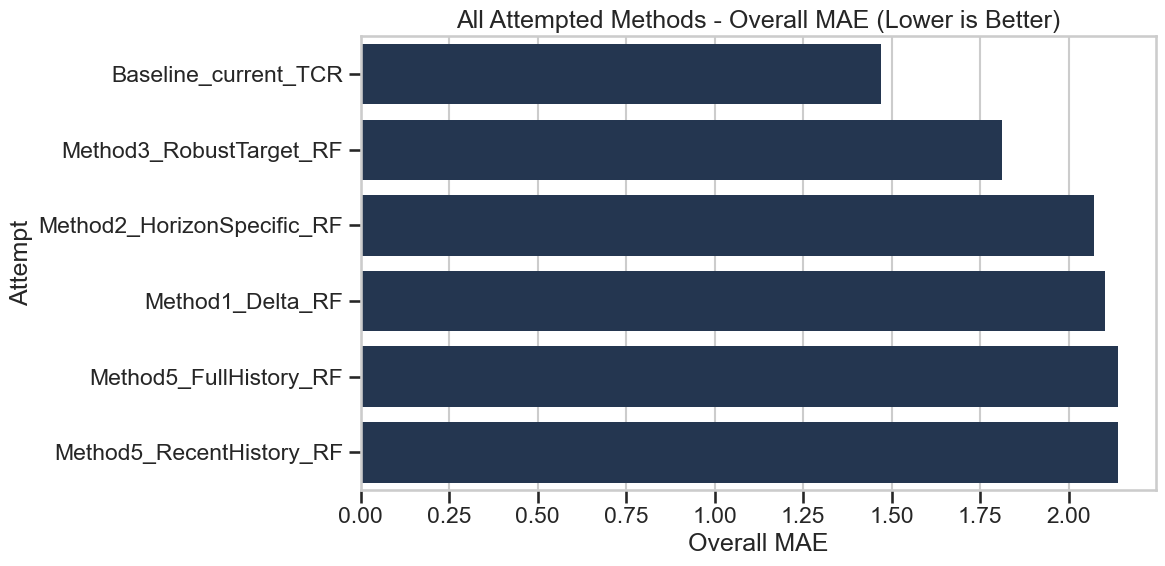

,attempt,overall_MAE,overall_RMSE,overall_R2
0,Baseline_current_TCR,1.470610,9.595227,-0.726217
1,Method3_RobustTarget_RF,1.813066,7.314746,0.014756
2,Method2_HorizonSpecific_RF,2.072177,7.312938,0.013781
3,Method1_Delta_RF,2.102646,8.205721,-0.248283
4,Method5_FullHistory_RF,2.138434,7.319390,0.011470
5,Method5_RecentHistory_RF,2.139985,7.307496,0.015669


In [42]:
# Combined scoreboard across all 5 attempted methods
combined_attempts = pd.DataFrame([
    {"attempt": "Baseline_current_TCR", "overall_MAE": baseline_overall["MAE"], "overall_RMSE": baseline_overall["RMSE"], "overall_R2": baseline_overall["R2"]},
    {"attempt": "Method1_Delta_RF", "overall_MAE": method1_overall["MAE"], "overall_RMSE": method1_overall["RMSE"], "overall_R2": method1_overall["R2"]},
    {"attempt": "Method2_HorizonSpecific_RF", "overall_MAE": method2_overall["MAE"], "overall_RMSE": method2_overall["RMSE"], "overall_R2": method2_overall["R2"]},
    {"attempt": "Method3_RobustTarget_RF", "overall_MAE": method3_overall["MAE"], "overall_RMSE": method3_overall["RMSE"], "overall_R2": method3_overall["R2"]},
    {"attempt": "Method5_FullHistory_RF", "overall_MAE": overall_full["MAE"], "overall_RMSE": overall_full["RMSE"], "overall_R2": overall_full["R2"]},
    {"attempt": "Method5_RecentHistory_RF", "overall_MAE": overall_recent["MAE"], "overall_RMSE": overall_recent["RMSE"], "overall_R2": overall_recent["R2"]},
])

combined_attempts = combined_attempts.sort_values("overall_MAE").reset_index(drop=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=combined_attempts, x="overall_MAE", y="attempt", color="#1d3557")
plt.title("All Attempted Methods - Overall MAE (Lower is Better)")
plt.xlabel("Overall MAE")
plt.ylabel("Attempt")
plt.tight_layout()
plt.show()

combined_attempts

## 18) Method 6 - Horizon-Wise Baseline Calibration (Linear)
Idea:
- Baseline may be directionally right but mis-calibrated in scale/offset.
- Fit horizon-specific linear calibrators from `current TCR -> future TCR` on train only.

Goal:
- Keep persistence structure while learning global mean-reversion adjustments.

In [43]:
# Method 6: Horizon-wise linear calibration from current-month TCR
from sklearn.linear_model import LinearRegression, HuberRegressor

X_train_tcr = X_train[[TARGET_COL]].values
X_test_tcr = X_test[[TARGET_COL]].values

calib_pred = np.zeros_like(y_test.values, dtype=float)
calib_rows = []

for i, h in enumerate(HORIZONS):
    # Huber is more robust to outliers than OLS
    model = HuberRegressor()
    model.fit(X_train_tcr, y_train.iloc[:, i].values)
    calib_pred[:, i] = model.predict(X_test_tcr)
    calib_rows.append({
        "horizon": f"t+{h}",
        "coef": float(model.coef_[0]),
        "intercept": float(model.intercept_),
    })

method6_scores = regression_metrics(y_test.values, calib_pred, horizon_names)
method6_overall = method6_scores.loc[method6_scores["horizon"] == "overall_mean"].iloc[0]

print("Method 6 calibration parameters:")
display(pd.DataFrame(calib_rows))

method6_summary = pd.DataFrame([
    {"strategy": "Baseline_current_TCR", "overall_MAE": baseline_overall["MAE"], "overall_RMSE": baseline_overall["RMSE"], "overall_R2": baseline_overall["R2"]},
    {"strategy": "Method6_LinearCalibration", "overall_MAE": method6_overall["MAE"], "overall_RMSE": method6_overall["RMSE"], "overall_R2": method6_overall["R2"]},
]).sort_values("overall_MAE")

print("Method 6 result:")
method6_summary

Method 6 calibration parameters:


,horizon,coef,intercept
0,t+1,0.018419,2.450498
1,t+2,0.012793,2.473948
2,t+3,0.012794,2.478948


Method 6 result:


,strategy,overall_MAE,overall_RMSE,overall_R2
1,Method6_LinearCalibration,1.46202,7.351754,0.004595
0,Baseline_current_TCR,1.47061,9.595227,-0.726217


## 19) Method 7 - Residual Learning with CV-Tuned Shrinkage
Idea:
- Predict residuals over baseline: `residual = y - baseline`.
- Apply shrinkage (`alpha`) to residual predictions, tuned on CV OOF train predictions.

Goal:
- Correct baseline only when there is reliable residual signal, avoid over-correction.

In [44]:
# Method 7: Residual model with CV-tuned shrinkage

baseline_train = np.column_stack([X_train[TARGET_COL].values] * 3)
residual_train = y_train.values - baseline_train

# OOF residual predictions for alpha tuning
cv_resid_pred = np.zeros_like(residual_train)
gkf = GroupKFold(n_splits=3)

for tr_idx, va_idx in gkf.split(X_train, y_train, groups=supervised.loc[is_train, MERCHANT_COL].values):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    r_tr = residual_train[tr_idx]

    resid_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    resid_model.fit(X_tr, r_tr)
    cv_resid_pred[va_idx] = resid_model.predict(X_va)

baseline_train_eval = baseline_train.copy()
y_train_eval = y_train.values

alpha_grid = np.linspace(0.0, 1.2, 25)
best_alpha = []
for i in range(3):
    mae_grid = []
    for a in alpha_grid:
        pred_i = baseline_train_eval[:, i] + a * cv_resid_pred[:, i]
        mae_grid.append(mean_absolute_error(y_train_eval[:, i], pred_i))
    best_alpha.append(float(alpha_grid[int(np.argmin(mae_grid))]))

# Fit final residual model on full training data
resid_model_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
resid_model_final.fit(X_train, residual_train)
resid_test_pred = resid_model_final.predict(X_test)

method7_pred = baseline_pred.copy()
for i in range(3):
    method7_pred[:, i] = baseline_pred[:, i] + best_alpha[i] * resid_test_pred[:, i]

method7_scores = regression_metrics(y_test.values, method7_pred, horizon_names)
method7_overall = method7_scores.loc[method7_scores["horizon"] == "overall_mean"].iloc[0]

print("Method 7 best shrinkage alpha by horizon:")
print({f"t+{h}": a for h, a in zip(HORIZONS, best_alpha)})

method7_summary = pd.DataFrame([
    {"strategy": "Baseline_current_TCR", "overall_MAE": baseline_overall["MAE"], "overall_RMSE": baseline_overall["RMSE"], "overall_R2": baseline_overall["R2"]},
    {"strategy": "Method7_ResidualShrinkage", "overall_MAE": method7_overall["MAE"], "overall_RMSE": method7_overall["RMSE"], "overall_R2": method7_overall["R2"]},
]).sort_values("overall_MAE")

print("Method 7 result:")
method7_summary

Method 7 best shrinkage alpha by horizon:
{'t+1': 0.85, 't+2': 0.85, 't+3': 0.8999999999999999}
Method 7 result:


,strategy,overall_MAE,overall_RMSE,overall_R2
0,Baseline_current_TCR,1.470610,9.595227,-0.726217
1,Method7_ResidualShrinkage,2.008004,8.012194,-0.188766


## 20) Method 8 - Recency-Weighted Training
Idea:
- Keep strict leakage-safe split but weight recent training months more heavily.

Goal:
- Improve adaptation to 2019 distribution without using any 2019 labels in training.

In [45]:
# Method 8: Recency-weighted RandomForest

train_dates = supervised.loc[is_train, DATE_COL].reset_index(drop=True)
months_from_start = ((train_dates.dt.year - train_dates.dt.year.min()) * 12 + (train_dates.dt.month - train_dates.dt.month.min())).astype(float)
recency_weights = np.exp(months_from_start / months_from_start.max())

rf_recency = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_recency.fit(X_train, y_train, sample_weight=recency_weights)

method8_pred = rf_recency.predict(X_test)
method8_scores = regression_metrics(y_test.values, method8_pred, horizon_names)
method8_overall = method8_scores.loc[method8_scores["horizon"] == "overall_mean"].iloc[0]

method8_summary = pd.DataFrame([
    {"strategy": "Baseline_current_TCR", "overall_MAE": baseline_overall["MAE"], "overall_RMSE": baseline_overall["RMSE"], "overall_R2": baseline_overall["R2"]},
    {"strategy": "Method8_RecencyWeighted_RF", "overall_MAE": method8_overall["MAE"], "overall_RMSE": method8_overall["RMSE"], "overall_R2": method8_overall["R2"]},
]).sort_values("overall_MAE")

print("Method 8 result:")
method8_summary

Method 8 result:


,strategy,overall_MAE,overall_RMSE,overall_R2
0,Baseline_current_TCR,1.470610,9.595227,-0.726217
1,Method8_RecencyWeighted_RF,2.142226,7.334577,0.007364


## 21) Method 9 - Leakage-Safe Stacking Blend
Idea:
- Blend baseline + robust method + residual-corrected method.
- Tune blend weights on training OOF predictions only.

Goal:
- Let baseline dominate where strong and use alternatives only where they add value.

In [46]:
# Method 9: Leakage-safe blending with train OOF weight search

groups_train = supervised.loc[is_train, MERCHANT_COL].values
gkf_blend = GroupKFold(n_splits=3)

# Build OOF predictions for two candidate correction models
oof_m3 = np.zeros_like(y_train.values)  # robust target RF style
oof_m7 = np.zeros_like(y_train.values)  # residual shrinkage style

for tr_idx, va_idx in gkf_blend.split(X_train, y_train, groups=groups_train):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    # Candidate A: robust target RF
    y_tr_rob = y_tr.copy()
    for c in y_tr_rob.columns:
        lo = y_tr_rob[c].quantile(0.01)
        hi = y_tr_rob[c].quantile(0.99)
        y_tr_rob[c] = y_tr_rob[c].clip(lo, hi)

    m3 = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        min_samples_split=5,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    m3.fit(X_tr, y_tr_rob)
    oof_m3[va_idx] = m3.predict(X_va)

    # Candidate B: residual model (no shrinkage at this stage)
    base_tr = np.column_stack([X_tr[TARGET_COL].values] * 3)
    resid_tr = y_tr.values - base_tr
    m7 = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    m7.fit(X_tr, resid_tr)

    base_va = np.column_stack([X_va[TARGET_COL].values] * 3)
    oof_m7[va_idx] = base_va + m7.predict(X_va)

oof_base = np.column_stack([X_train[TARGET_COL].values] * 3)
y_true_train = y_train.values

w_grid = np.linspace(0, 1, 21)
best_w = None
best_mae = np.inf

# Weights: final = w0*baseline + w1*m3 + w2*m7, w0=1-w1-w2, all nonnegative
for w1 in w_grid:
    for w2 in w_grid:
        if w1 + w2 > 1:
            continue
        w0 = 1 - w1 - w2
        oof_blend = w0 * oof_base + w1 * oof_m3 + w2 * oof_m7
        mae = mean_absolute_error(y_true_train, oof_blend)
        if mae < best_mae:
            best_mae = mae
            best_w = (w0, w1, w2)

# Fit full versions for test inference
m3_full = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
y_train_rob_full = y_train.copy()
for c in y_train_rob_full.columns:
    lo = y_train_rob_full[c].quantile(0.01)
    hi = y_train_rob_full[c].quantile(0.99)
    y_train_rob_full[c] = y_train_rob_full[c].clip(lo, hi)
m3_full.fit(X_train, y_train_rob_full)
test_m3 = m3_full.predict(X_test)

m7_full = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
base_train_full = np.column_stack([X_train[TARGET_COL].values] * 3)
resid_train_full = y_train.values - base_train_full
m7_full.fit(X_train, resid_train_full)
test_m7 = baseline_pred + m7_full.predict(X_test)

w0, w1, w2 = best_w
method9_pred = w0 * baseline_pred + w1 * test_m3 + w2 * test_m7

method9_scores = regression_metrics(y_test.values, method9_pred, horizon_names)
method9_overall = method9_scores.loc[method9_scores["horizon"] == "overall_mean"].iloc[0]

print("Method 9 best blend weights (baseline, robustRF, residualRF):", best_w)
print("Method 9 OOF train MAE:", round(best_mae, 6))

method9_summary = pd.DataFrame([
    {"strategy": "Baseline_current_TCR", "overall_MAE": baseline_overall["MAE"], "overall_RMSE": baseline_overall["RMSE"], "overall_R2": baseline_overall["R2"]},
    {"strategy": "Method9_StackedBlend", "overall_MAE": method9_overall["MAE"], "overall_RMSE": method9_overall["RMSE"], "overall_R2": method9_overall["R2"]},
]).sort_values("overall_MAE")

print("Method 9 result:")
method9_summary

Method 9 best blend weights (baseline, robustRF, residualRF): (np.float64(0.0), np.float64(1.0), np.float64(0.0))
Method 9 OOF train MAE: 2.033183
Method 9 result:


,strategy,overall_MAE,overall_RMSE,overall_R2
0,Baseline_current_TCR,1.470610,9.595227,-0.726217
1,Method9_StackedBlend,1.814063,7.315800,0.014481


## 22) Extended Scoreboard (Methods 1-9)
This table extends tracking to all new attempts beyond the original five methods.

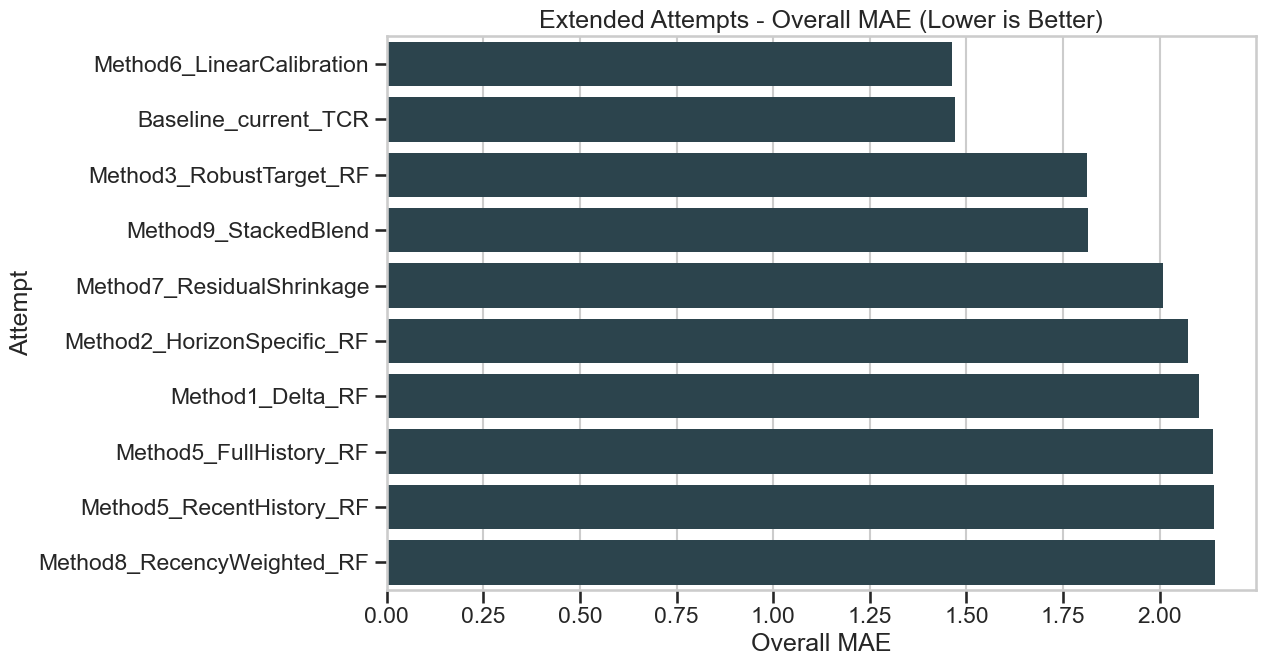

,attempt,overall_MAE,overall_RMSE,overall_R2
0,Method6_LinearCalibration,1.462020,7.351754,0.004595
1,Baseline_current_TCR,1.470610,9.595227,-0.726217
2,Method3_RobustTarget_RF,1.813066,7.314746,0.014756
3,Method9_StackedBlend,1.814063,7.315800,0.014481
4,Method7_ResidualShrinkage,2.008004,8.012194,-0.188766
5,Method2_HorizonSpecific_RF,2.072177,7.312938,0.013781
6,Method1_Delta_RF,2.102646,8.205721,-0.248283
7,Method5_FullHistory_RF,2.138434,7.319390,0.011470
8,Method5_RecentHistory_RF,2.139985,7.307496,0.015669
9,Method8_RecencyWeighted_RF,2.142226,7.334577,0.007364


In [47]:
# Extended scoreboard across methods 1-9
extended_attempts = pd.DataFrame([
    {"attempt": "Baseline_current_TCR", "overall_MAE": baseline_overall["MAE"], "overall_RMSE": baseline_overall["RMSE"], "overall_R2": baseline_overall["R2"]},
    {"attempt": "Method1_Delta_RF", "overall_MAE": method1_overall["MAE"], "overall_RMSE": method1_overall["RMSE"], "overall_R2": method1_overall["R2"]},
    {"attempt": "Method2_HorizonSpecific_RF", "overall_MAE": method2_overall["MAE"], "overall_RMSE": method2_overall["RMSE"], "overall_R2": method2_overall["R2"]},
    {"attempt": "Method3_RobustTarget_RF", "overall_MAE": method3_overall["MAE"], "overall_RMSE": method3_overall["RMSE"], "overall_R2": method3_overall["R2"]},
    {"attempt": "Method5_FullHistory_RF", "overall_MAE": overall_full["MAE"], "overall_RMSE": overall_full["RMSE"], "overall_R2": overall_full["R2"]},
    {"attempt": "Method5_RecentHistory_RF", "overall_MAE": overall_recent["MAE"], "overall_RMSE": overall_recent["RMSE"], "overall_R2": overall_recent["R2"]},
    {"attempt": "Method6_LinearCalibration", "overall_MAE": method6_overall["MAE"], "overall_RMSE": method6_overall["RMSE"], "overall_R2": method6_overall["R2"]},
    {"attempt": "Method7_ResidualShrinkage", "overall_MAE": method7_overall["MAE"], "overall_RMSE": method7_overall["RMSE"], "overall_R2": method7_overall["R2"]},
    {"attempt": "Method8_RecencyWeighted_RF", "overall_MAE": method8_overall["MAE"], "overall_RMSE": method8_overall["RMSE"], "overall_R2": method8_overall["R2"]},
    {"attempt": "Method9_StackedBlend", "overall_MAE": method9_overall["MAE"], "overall_RMSE": method9_overall["RMSE"], "overall_R2": method9_overall["R2"]},
]).sort_values("overall_MAE").reset_index(drop=True)

plt.figure(figsize=(13, 7))
sns.barplot(data=extended_attempts, x="overall_MAE", y="attempt", color="#264653")
plt.title("Extended Attempts - Overall MAE (Lower is Better)")
plt.xlabel("Overall MAE")
plt.ylabel("Attempt")
plt.tight_layout()
plt.show()

extended_attempts

## 23) Archival Decision Summary

This archival notebook records all tested methods under strict leakage-safe evaluation.  
Method 6 (linear calibration of persistence) is the selected method for continuation because it achieves the best overall MAE in the current results table while preserving an interpretable structure.  
Further development, robustness checks, and potential productionization experiments will continue in a separate notebook.

In [57]:
# Archival decision summary table
if "extended_attempts" not in locals():
    raise ValueError("extended_attempts table not found. Run the scoreboard cell first.")

decision_table = extended_attempts.copy().sort_values("overall_MAE").reset_index(drop=True)
baseline_mae = float(decision_table.loc[decision_table["attempt"] == "Baseline_current_TCR", "overall_MAE"].iloc[0])

decision_table["mae_vs_baseline"] = decision_table["overall_MAE"] - baseline_mae
decision_table["improvement_vs_baseline_pct"] = (
    (baseline_mae - decision_table["overall_MAE"]) / baseline_mae * 100
)

display(decision_table)

top_attempt = decision_table.iloc[0]["attempt"]
top_mae = float(decision_table.iloc[0]["overall_MAE"])
print("Selected archival handoff method:", top_attempt)
print("Top overall MAE:", round(top_mae, 6))
print("Baseline overall MAE:", round(baseline_mae, 6))

,attempt,overall_MAE,overall_RMSE,overall_R2,mae_vs_baseline,improvement_vs_baseline_pct
0,Method6_LinearCalibration,1.462020,7.351754,0.004595,-0.008590,0.584109
1,Baseline_current_TCR,1.470610,9.595227,-0.726217,0.000000,0.000000
2,Method3_RobustTarget_RF,1.813066,7.314746,0.014756,0.342456,-23.286632
3,Method9_StackedBlend,1.814063,7.315800,0.014481,0.343453,-23.354427
4,Method7_ResidualShrinkage,2.008004,8.012194,-0.188766,0.537393,-36.542192
5,Method2_HorizonSpecific_RF,2.072177,7.312938,0.013781,0.601567,-40.905935
6,Method1_Delta_RF,2.102646,8.205721,-0.248283,0.632035,-42.977763
7,Method5_FullHistory_RF,2.138434,7.319390,0.011470,0.667824,-45.411324
8,Method5_RecentHistory_RF,2.139985,7.307496,0.015669,0.669375,-45.516795
9,Method8_RecencyWeighted_RF,2.142226,7.334577,0.007364,0.671616,-45.669199


Selected archival handoff method: Method6_LinearCalibration
Top overall MAE: 1.46202
Baseline overall MAE: 1.47061


## 24) Final 10-Merchant Visualization (Expanded Methods)

This final figure replicates the explicit t versus t+1..t+3 timeline view for 10 test merchants and includes baseline plus the newly attempted methods.  
It is intended as the archival end-cap visualization for report submission.

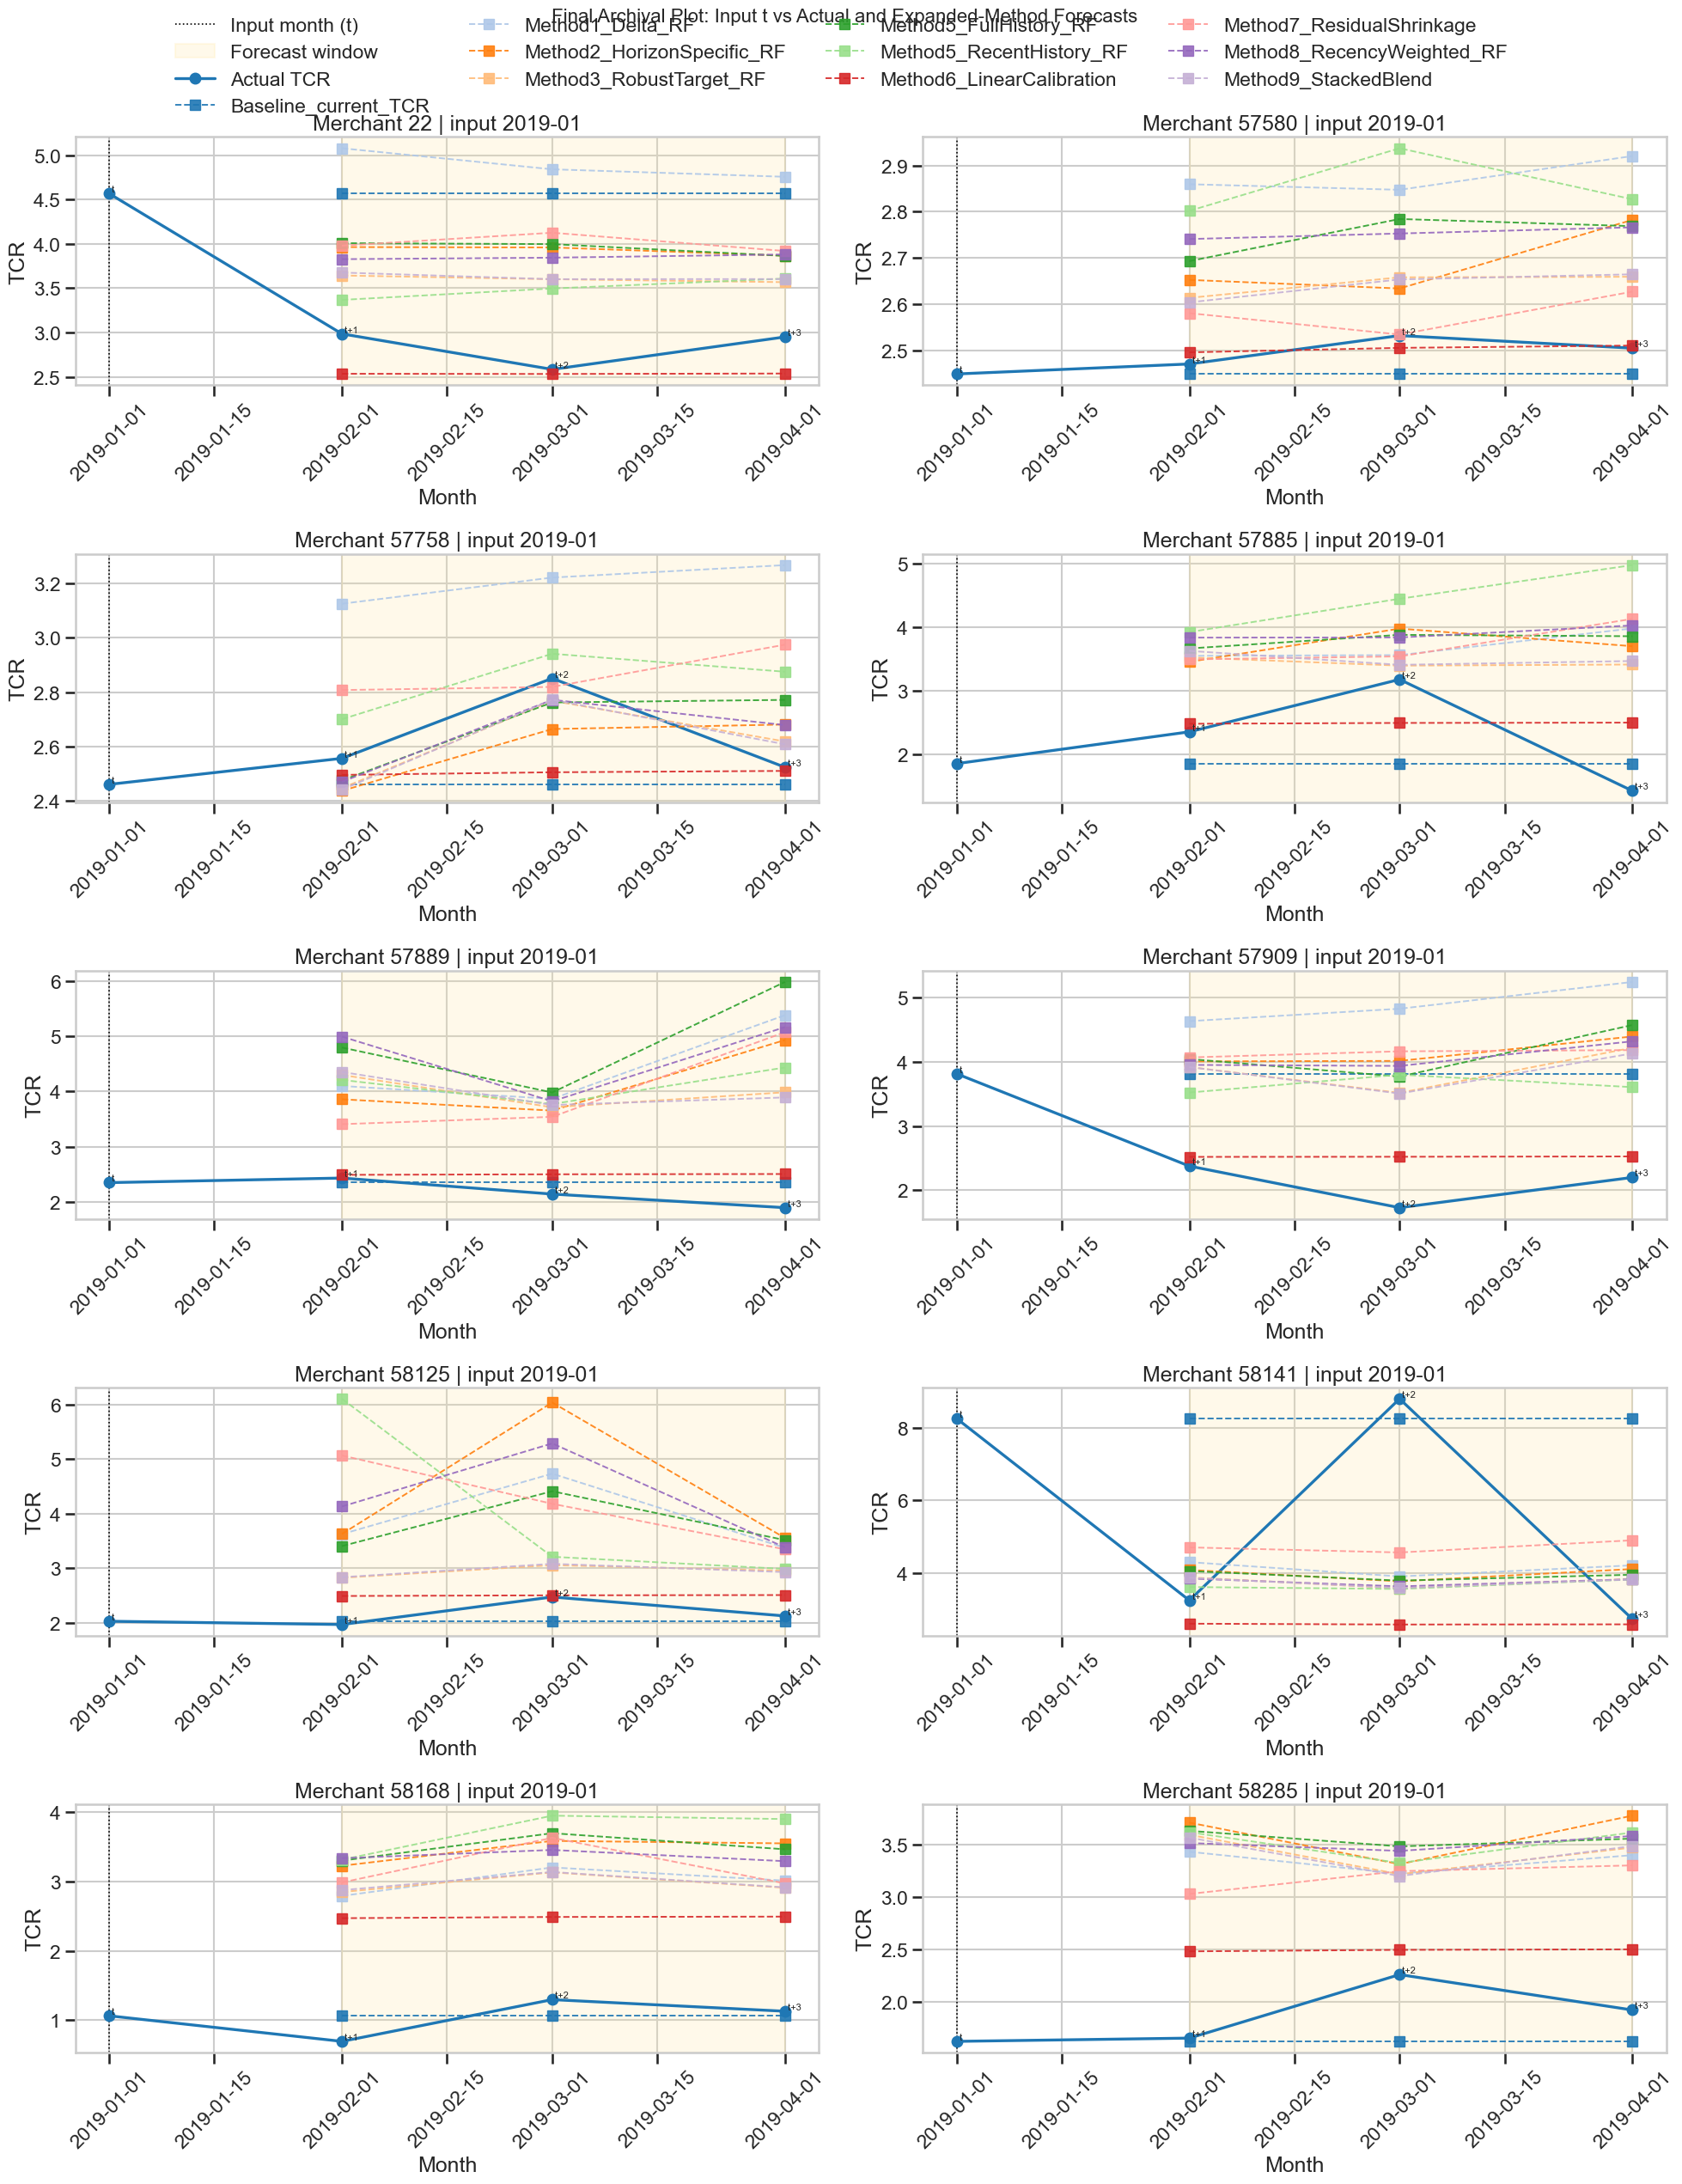

,model,overall_MAE,overall_RMSE,overall_R2
0,Method6_LinearCalibration,1.462020,7.351754,0.004595
1,Baseline_current_TCR,1.470610,9.595227,-0.726217
2,Method3_RobustTarget_RF,1.813066,7.314746,0.014756
3,Method9_StackedBlend,1.814063,7.315800,0.014481
4,Method7_ResidualShrinkage,2.008004,8.012194,-0.188766
5,Method2_HorizonSpecific_RF,2.072177,7.312938,0.013781
6,Method1_Delta_RF,2.102646,8.205721,-0.248283
7,Method5_FullHistory_RF,2.138434,7.319390,0.011470
8,Method5_RecentHistory_RF,2.139985,7.307496,0.015669
9,Method8_RecencyWeighted_RF,2.142226,7.334577,0.007364


In [58]:
# Final replicated 10-merchant timeline visualization for expanded methods
attempt_prediction_store = {
    "Baseline_current_TCR": baseline_pred,
    "Method1_Delta_RF": rf_delta_abs_pred if "rf_delta_abs_pred" in locals() else None,
    "Method2_HorizonSpecific_RF": horizon_pred if "horizon_pred" in locals() else None,
    "Method3_RobustTarget_RF": robust_pred if "robust_pred" in locals() else None,
    "Method5_FullHistory_RF": pred_full if "pred_full" in locals() else None,
    "Method5_RecentHistory_RF": pred_recent if "pred_recent" in locals() else None,
    "Method6_LinearCalibration": calib_pred if "calib_pred" in locals() else None,
    "Method7_ResidualShrinkage": method7_pred if "method7_pred" in locals() else None,
    "Method8_RecencyWeighted_RF": method8_pred if "method8_pred" in locals() else None,
    "Method9_StackedBlend": method9_pred if "method9_pred" in locals() else None,
}
attempt_prediction_store = {k: v for k, v in attempt_prediction_store.items() if v is not None}

# Build compact plotting frame aligned to test rows
test_meta = supervised.loc[is_test, [MERCHANT_COL, DATE_COL]].reset_index(drop=True).copy()
timeline_df = test_meta.copy()
timeline_df["input_tcr_t"] = X_test[TARGET_COL].reset_index(drop=True)
for i, h in enumerate(HORIZONS):
    timeline_df[f"actual_t_plus_{h}"] = y_test.iloc[:, i].reset_index(drop=True)

for name, arr in attempt_prediction_store.items():
    for i, h in enumerate(HORIZONS):
        timeline_df[f"{name}_pred_t_plus_{h}"] = arr[:, i]

# Select 10 merchants with most test rows, then one canonical row each
merchant_counts = timeline_df.groupby(MERCHANT_COL)[DATE_COL].size().sort_values(ascending=False)
selected_merchants = merchant_counts.head(min(10, len(merchant_counts))).index.tolist()

plot_rows = (
    timeline_df[timeline_df[MERCHANT_COL].isin(selected_merchants)]
    .sort_values([MERCHANT_COL, DATE_COL])
    .groupby(MERCHANT_COL, as_index=False)
    .first()
)

n_merchants = len(plot_rows)
n_cols = 2
n_rows = int(np.ceil(n_merchants / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

model_names = list(attempt_prediction_store.keys())
palette = dict(zip(model_names, sns.color_palette("tab20", n_colors=len(model_names))))

for i, row in plot_rows.iterrows():
    ax = axes[i]
    merchant = row[MERCHANT_COL]
    t_date = row[DATE_COL]

    x_dates = [t_date + pd.DateOffset(months=h) for h in [0, 1, 2, 3]]
    horizon_dates = x_dates[1:]
    labels = ["t", "t+1", "t+2", "t+3"]

    actual_series = [
        row["input_tcr_t"],
        row["actual_t_plus_1"],
        row["actual_t_plus_2"],
        row["actual_t_plus_3"],
    ]

    ax.axvline(x_dates[0], color="black", linestyle=":", linewidth=1.2, label="Input month (t)")
    ax.axvspan(x_dates[1], x_dates[3], color="#ffe8a1", alpha=0.22, label="Forecast window")
    ax.plot(x_dates, actual_series, marker="o", linewidth=2.4, color="#1f77b4", label="Actual TCR")

    for name in model_names:
        preds = [
            row[f"{name}_pred_t_plus_1"],
            row[f"{name}_pred_t_plus_2"],
            row[f"{name}_pred_t_plus_3"],
        ]
        ax.plot(
            horizon_dates,
            preds,
            marker="s",
            linestyle="--",
            linewidth=1.4,
            alpha=0.9,
            color=palette[name],
            label=name,
        )

    for xd, yd, lb in zip(x_dates, actual_series, labels):
        if pd.notna(yd):
            ax.text(xd, yd, f" {lb}", fontsize=8, va="bottom")

    ax.set_title(f"Merchant {merchant} | input {t_date.strftime('%Y-%m')}")
    ax.set_xlabel("Month")
    ax.set_ylabel("TCR")
    ax.tick_params(axis="x", rotation=45)

for j in range(n_merchants, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc="upper center", ncol=4, frameon=False)
fig.suptitle("Final Archival Plot: Input t vs Actual and Expanded-Method Forecasts", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Optional compact MAE table for included models
rows = []
for name, arr in attempt_prediction_store.items():
    m = regression_metrics(y_test.values, arr, [f"t+{h}" for h in HORIZONS])
    o = m[m["horizon"] == "overall_mean"].iloc[0]
    rows.append({"model": name, "overall_MAE": o["MAE"], "overall_RMSE": o["RMSE"], "overall_R2": o["R2"]})

final_plot_scoreboard = pd.DataFrame(rows).sort_values("overall_MAE").reset_index(drop=True)
display(final_plot_scoreboard)